<a href="https://colab.research.google.com/github/YonghwanYim/CMAPSS-Experiments/blob/main/RL_Exp_4_failure_probability_30_450epi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reinforcement Learning with random observation
(NASA C-MAPSS dataset)

# Data Handling

Connect with Google Drive

In [1]:
from google.colab import drive
drive.mount('content')

Mounted at content


Importing libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import sklearn
from sklearn.metrics import mean_squared_error, r2_score
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import random
import warnings
np.random.seed(34)
warnings.filterwarnings('ignore')

Defining features names

In [3]:
index_names = ['unit_number', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['s_{}'.format(i+1) for i in range(0,21)]
col_names = index_names + setting_names + sensor_names

Importing train and validation data

* Data Set : FD001
* Train trajectories : 100
* Test trajectories : 100
* Conditions : ONE (Sea Level)
* Fault Modes : ONE (HPC Degradation)

Each engine starts with different degrees of initial wear and manufacturing variation which is unknown to the user. This wear and variation is considered normal, i.e., it is not considered a fault condition. here are three operational settings that have a substantial effect on engine performance. These settings are also included in the data. The data is contaminated with sensor noise.

The engine is operating normally at the start of each time series, and develops a fault at some point during the series. In the training set, the fault grows in magnitude until system failure. In the test set, the time series ends some time prior to system failure. The objective of the competition is to predict the number of remaining operational cycles before failure in the test set, i.e., the number of operational cycles after the last cycle that the engine will continue to operate. Also provided a vector of true Remaining Useful Life (RUL) values for the test data.





**Data Set: FD002**
*   Train trjectories: 260
*   Conditions: SIX
*   Fault Modes: ONE (HPC Degradation)

**Data Set: FD003**
* Train trjectories: 100
* Conditions: ONE (Sea Level)
* Fault Modes: TWO (HPC Degradation, Fan Degradation)

**Data Set: FD004**
* Train trjectories: 249
* Conditions: SIX
* Fault Modes: TWO (HPC Degradation, Fan Degradation)

In [4]:
dftrain = pd.read_csv('/content/content/MyDrive/Colab Notebooks/NASA_Turbofan_Data/train_FD001_1_70.txt',sep='\s+',header=None,index_col=False,names=col_names)
dfvalid = pd.read_csv('/content/content/MyDrive/Colab Notebooks/NASA_Turbofan_Data/train_FD001_71_100.txt',sep='\s+',header=None,index_col=False,names=col_names)
dffull_data = pd.read_csv('/content/content/MyDrive/Colab Notebooks/NASA_Turbofan_Data/train_FD001.txt',sep='\s+',header=None,index_col=False,names=col_names)
# y_valid : A vector of true Remaining Useful Life (RUL) values for the test data.
# y_valid = pd.read_csv('/content/content/MyDrive/Colab Notebooks/NASA_Turbofan_Data/RUL_FD001.txt',sep='\s+',header=None,index_col=False,names=['RUL'])
# dfvalid.shape

In [5]:
train = dftrain.copy() # Engine 1~70 (dataset 1)
valid = dfvalid.copy() # Engine 71~100 (dataset 1)
full_data = dffull_data.copy() # Engine 1~100 (dataset 1)

Data inspection

In [6]:
train

,unit_number,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14125,70,133,-0.0015,-0.0001,100.0,518.67,644.10,1601.31,1430.27,14.62,...,519.83,2388.23,8167.97,8.4984,0.03,396,2388,100.0,38.41,23.1364
14126,70,134,-0.0012,-0.0004,100.0,518.67,644.09,1605.88,1430.21,14.62,...,519.38,2388.18,8172.19,8.5328,0.03,397,2388,100.0,38.28,23.0637
14127,70,135,0.0004,0.0003,100.0,518.67,643.55,1596.63,1426.86,14.62,...,519.38,2388.20,8167.46,8.5118,0.03,396,2388,100.0,38.48,23.0993
14128,70,136,-0.0044,0.0000,100.0,518.67,643.79,1601.30,1427.36,14.62,...,519.77,2388.25,8165.57,8.5529,0.03,398,2388,100.0,38.24,23.0289


In [7]:
valid

,unit_number,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,71,1,0.0027,-0.0004,100.0,518.67,642.64,1581.95,1407.04,14.62,...,521.90,2388.13,8126.82,8.4372,0.03,391,2388,100.0,38.99,23.2399
1,71,2,0.0029,-0.0003,100.0,518.67,642.82,1593.17,1403.53,14.62,...,521.24,2388.10,8124.84,8.4068,0.03,392,2388,100.0,38.85,23.2887
2,71,3,0.0007,0.0003,100.0,518.67,642.50,1582.94,1402.54,14.62,...,521.85,2388.09,8123.24,8.4233,0.03,394,2388,100.0,38.92,23.3668
3,71,4,-0.0014,0.0003,100.0,518.67,643.04,1584.90,1409.75,14.62,...,521.62,2388.08,8123.70,8.4352,0.03,392,2388,100.0,38.89,23.2722
4,71,5,0.0015,0.0001,100.0,518.67,642.00,1587.63,1400.43,14.62,...,521.50,2388.04,8123.08,8.4395,0.03,393,2388,100.0,39.03,23.2896
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6496,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
6497,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
6498,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
6499,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640


In [8]:
full_data

,unit_number,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640


In [9]:
print('Shape of the train dataset : ',train.shape)
print('Shape of the validation dataset : ',valid.shape)
print('Percentage of the validation dataset : ',len(valid)/(len(valid)+len(train)))

Shape of the train dataset :  (14130, 26)
Shape of the validation dataset :  (6501, 26)
Percentage of the validation dataset :  0.31510833212156464


Add RUL column to the data

RUL corresponds to the remaining time cycles for each unit before it falls.

In [10]:
def add_RUL_column(df):
    train_grouped_by_unit = df.groupby(by='unit_number')
    max_time_cycles = train_grouped_by_unit['time_cycles'].max()
    merged = df.merge(max_time_cycles.to_frame(name='max_time_cycle'), left_on='unit_number',right_index=True)
    merged["RUL"] = merged["max_time_cycle"] - merged['time_cycles']
    merged = merged.drop("max_time_cycle", axis=1)
    return merged

In [11]:
train = add_RUL_column(train)
valid = add_RUL_column(valid)
full_data = add_RUL_column(full_data)

In [12]:
train[['unit_number','RUL']] # Jet Engine 1~70 (total : 70)

,unit_number,RUL
0,1,191
1,1,190
2,1,189
3,1,188
4,1,187
...,...,...
14125,70,4
14126,70,3
14127,70,2
14128,70,1


In [13]:
valid[['unit_number','RUL']] # Jet Engine 71~100 (total : 30)

,unit_number,RUL
0,71,207
1,71,206
2,71,205
3,71,204
4,71,203
...,...,...
6496,100,4
6497,100,3
6498,100,2
6499,100,1


In [14]:
full_data[['unit_number', 'RUL']]

,unit_number,RUL
0,1,191
1,1,190
2,1,189
3,1,188
4,1,187
...,...,...
20626,100,4
20627,100,3
20628,100,2
20629,100,1


In [15]:
Sensor_dictionary={}
dict_list=[ "(Fan inlet temperature) (◦R)",
"(LPC outlet temperature) (◦R)",
"(HPC outlet temperature) (◦R)",
"(LPT outlet temperature) (◦R)",
"(Fan inlet Pressure) (psia)",
"(bypass-duct pressure) (psia)",
"(HPC outlet pressure) (psia)",
"(Physical fan speed) (rpm)",
"(Physical core speed) (rpm)",
"(Engine pressure ratio(P50/P2)",
"(HPC outlet Static pressure) (psia)",
"(Ratio of fuel flow to Ps30) (pps/psia)",
"(Corrected fan speed) (rpm)",
"(Corrected core speed) (rpm)",
"(Bypass Ratio) ",
"(Burner fuel-air ratio)",
"(Bleed Enthalpy)",
"(Required fan speed)",
"(Required fan conversion speed)",
"(High-pressure turbines Cool air flow)",
"(Low-pressure turbines Cool air flow)" ]
i=1
for x in dict_list :
    Sensor_dictionary['s_'+str(i)]=x
    i+=1
Sensor_dictionary

{'s_1': '(Fan inlet temperature) (◦R)',
 's_2': '(LPC outlet temperature) (◦R)',
 's_3': '(HPC outlet temperature) (◦R)',
 's_4': '(LPT outlet temperature) (◦R)',
 's_5': '(Fan inlet Pressure) (psia)',
 's_6': '(bypass-duct pressure) (psia)',
 's_7': '(HPC outlet pressure) (psia)',
 's_8': '(Physical fan speed) (rpm)',
 's_9': '(Physical core speed) (rpm)',
 's_10': '(Engine pressure ratio(P50/P2)',
 's_11': '(HPC outlet Static pressure) (psia)',
 's_12': '(Ratio of fuel flow to Ps30) (pps/psia)',
 's_13': '(Corrected fan speed) (rpm)',
 's_14': '(Corrected core speed) (rpm)',
 's_15': '(Bypass Ratio) ',
 's_16': '(Burner fuel-air ratio)',
 's_17': '(Bleed Enthalpy)',
 's_18': '(Required fan speed)',
 's_19': '(Required fan conversion speed)',
 's_20': '(High-pressure turbines Cool air flow)',
 's_21': '(Low-pressure turbines Cool air flow)'}

Plotting the evolution of features (sensors) along with the evolution with RUL

In [16]:
def plot_signal(df, Sensor_dic, signal_name):
    plt.figure(figsize=(13,5))
    for i in df['unit_number'].unique():
      #plt.plot('RUL', signal_name, data=df[df['unit_number']==i].rolling(10).mean())
       if (i % 5 == 0):   #For a better visualisation, we plot the sensors signals of 10 units only (data : FD001)
           plt.plot('RUL', signal_name, data=df[df['unit_number']==i].rolling(10).mean())

    plt.xlim(250, 0)  # reverse the x-axis so RUL counts down to zero  # xlim() : range of x-axis
    plt.xticks(np.arange(0, 300, 25))
    plt.ylabel(Sensor_dic[signal_name])
    plt.xlabel('Remaining Useful Life')
    plt.show()

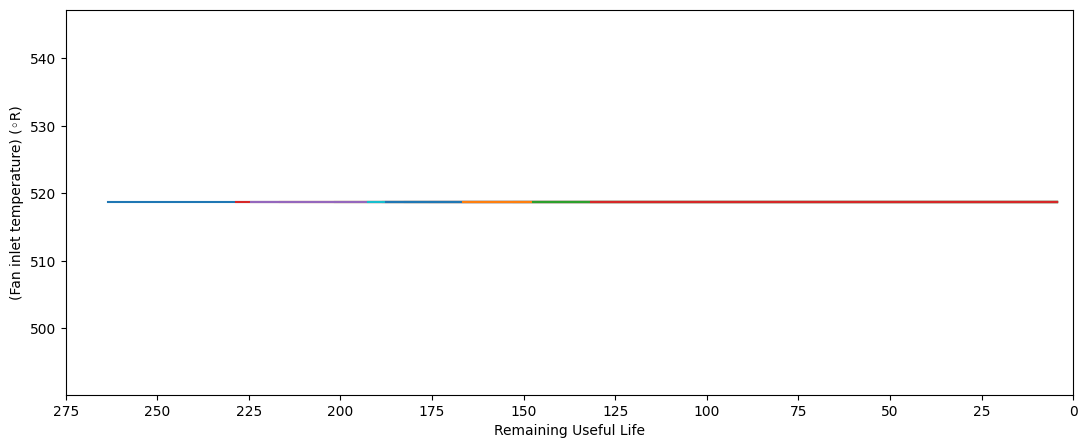

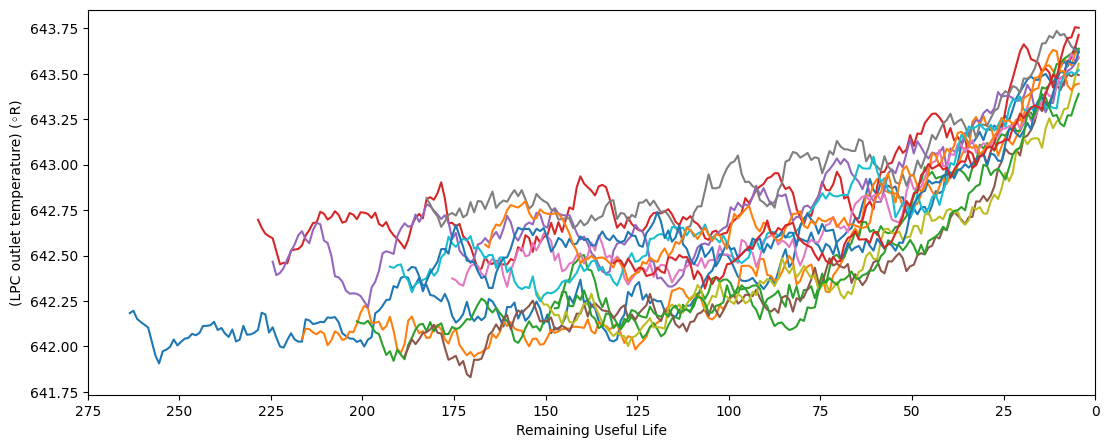

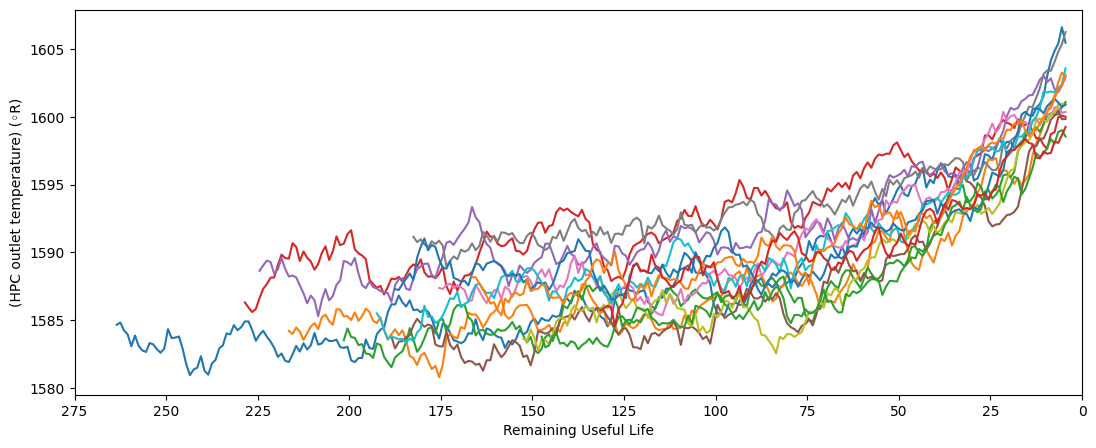

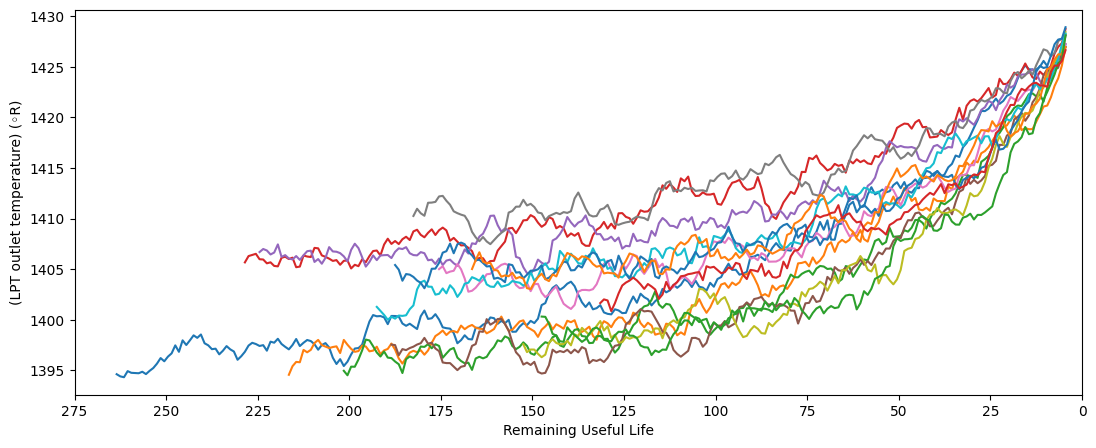

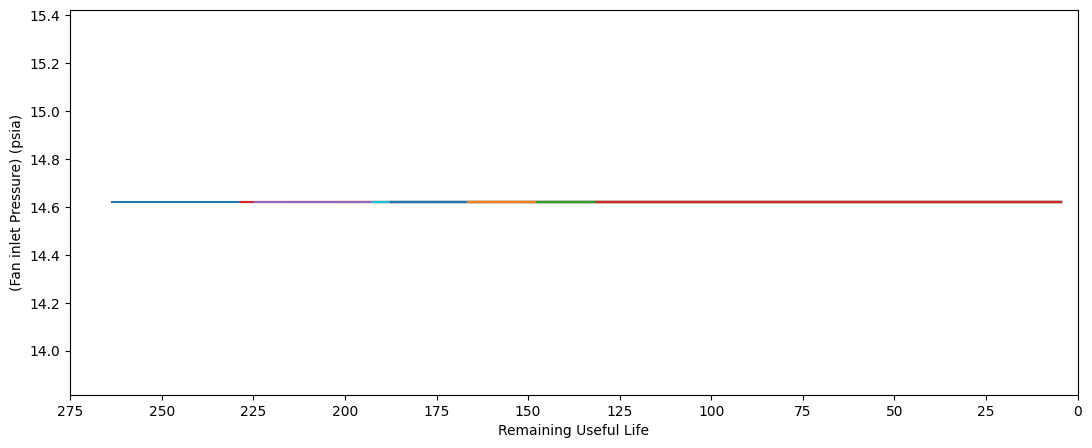

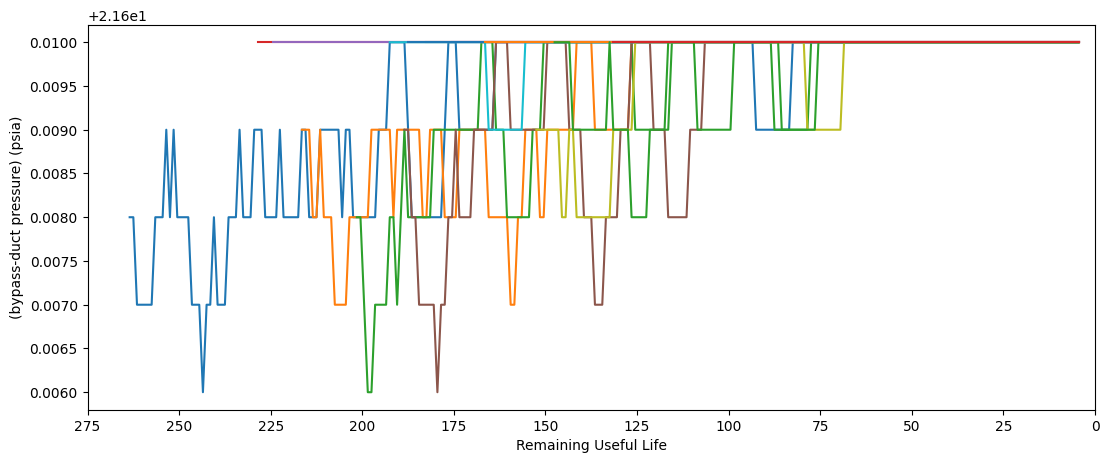

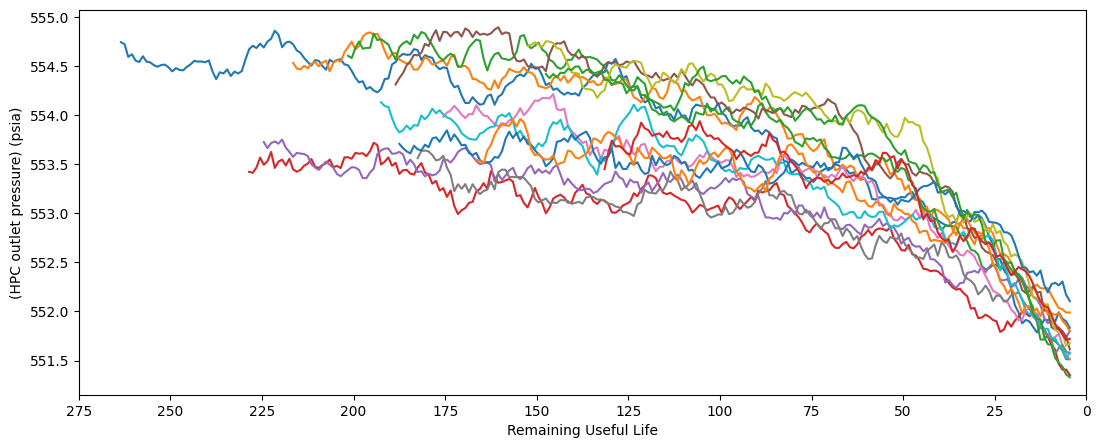

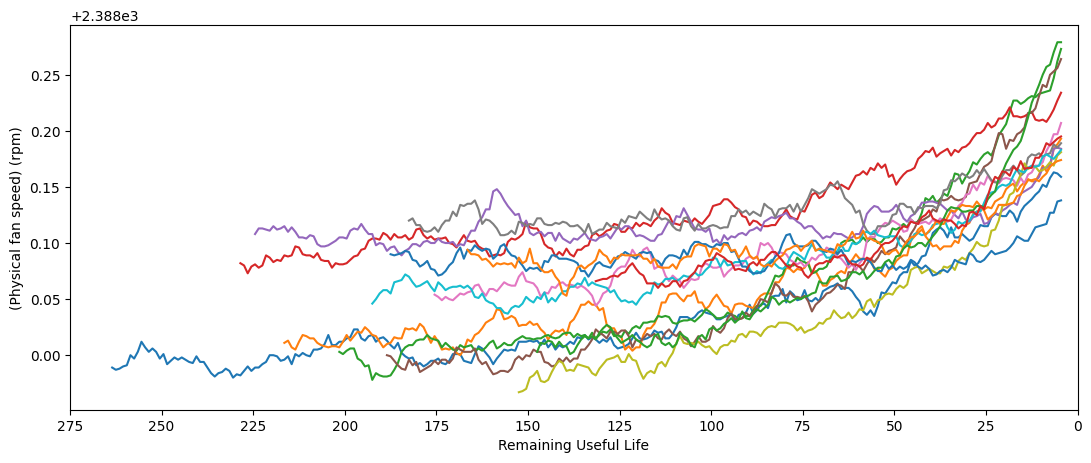

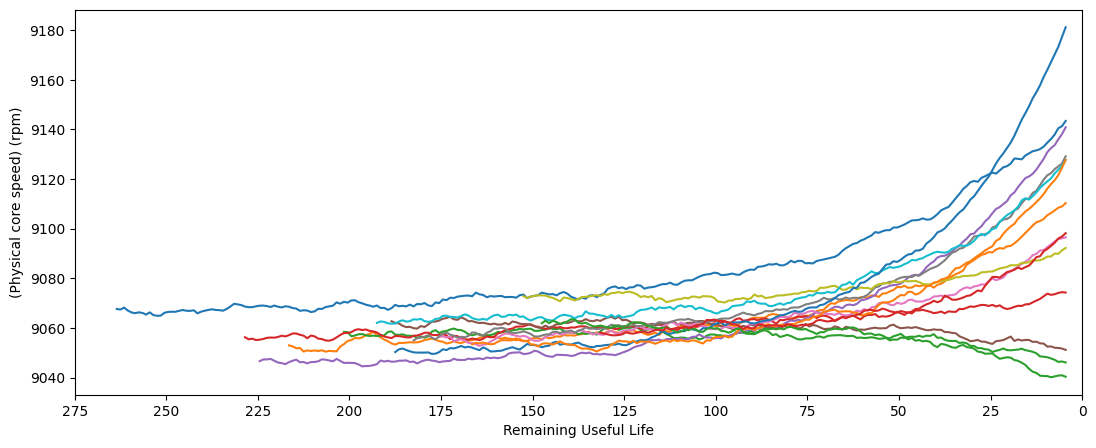

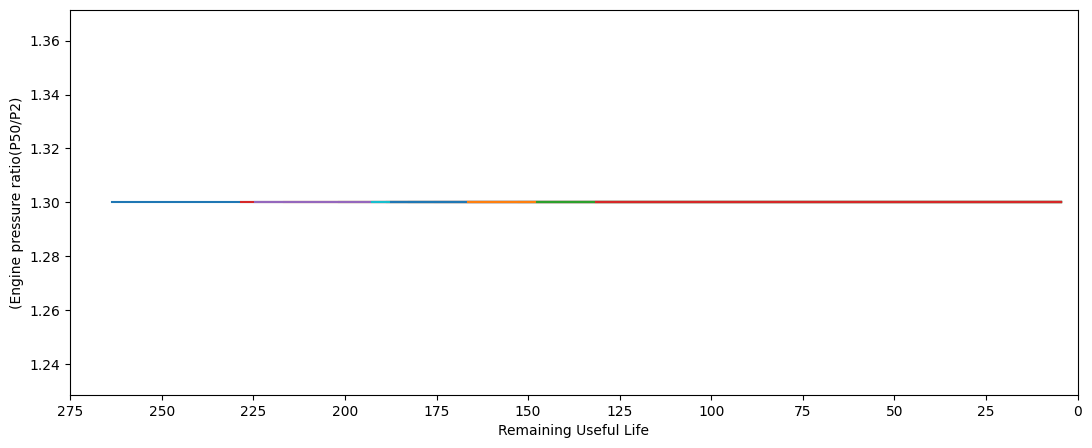

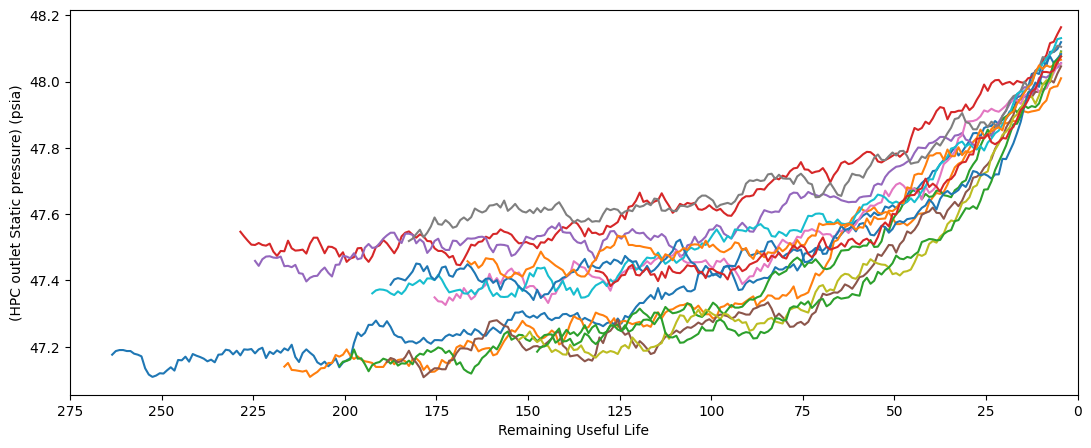

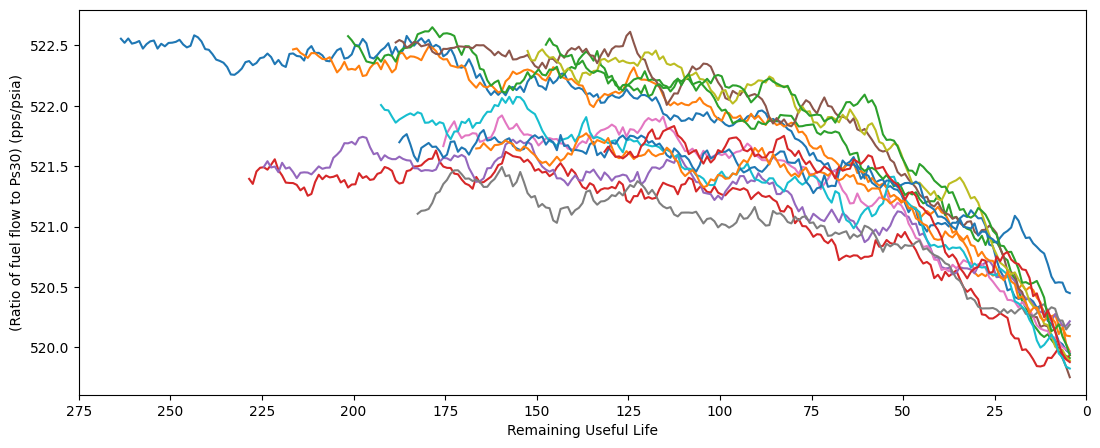

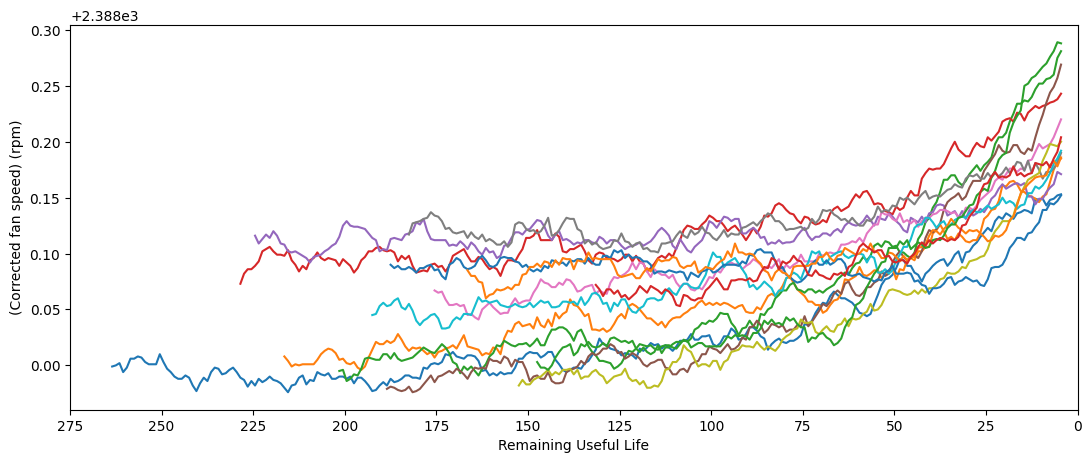

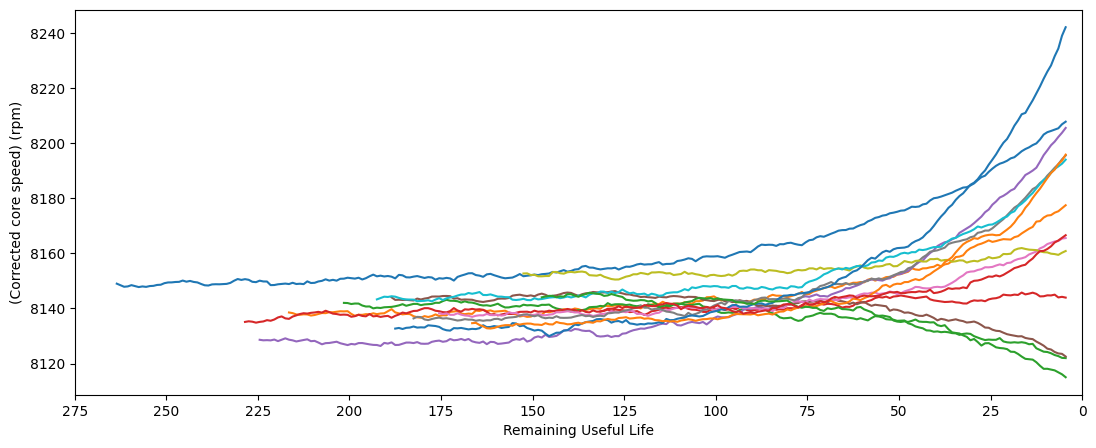

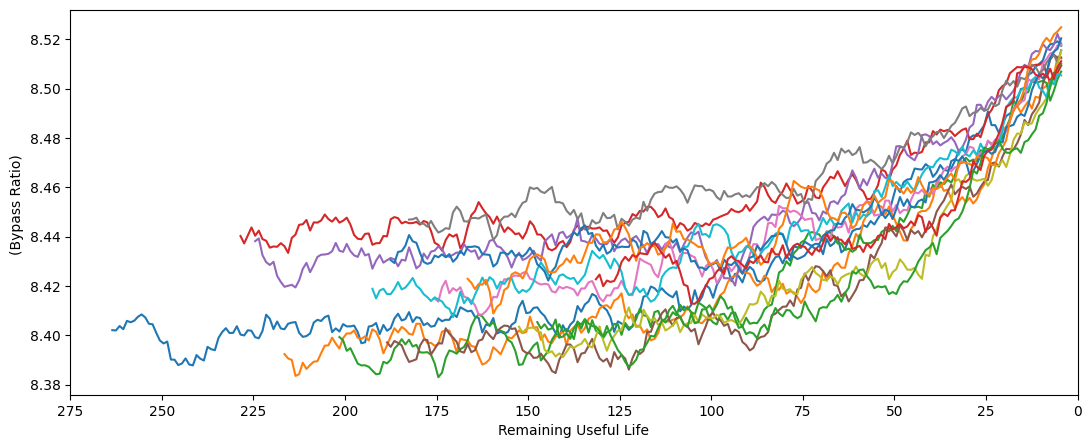

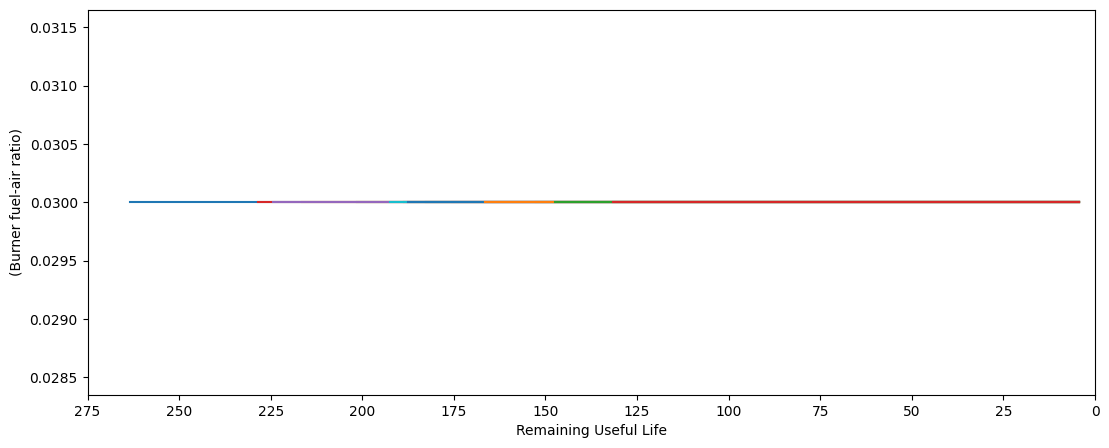

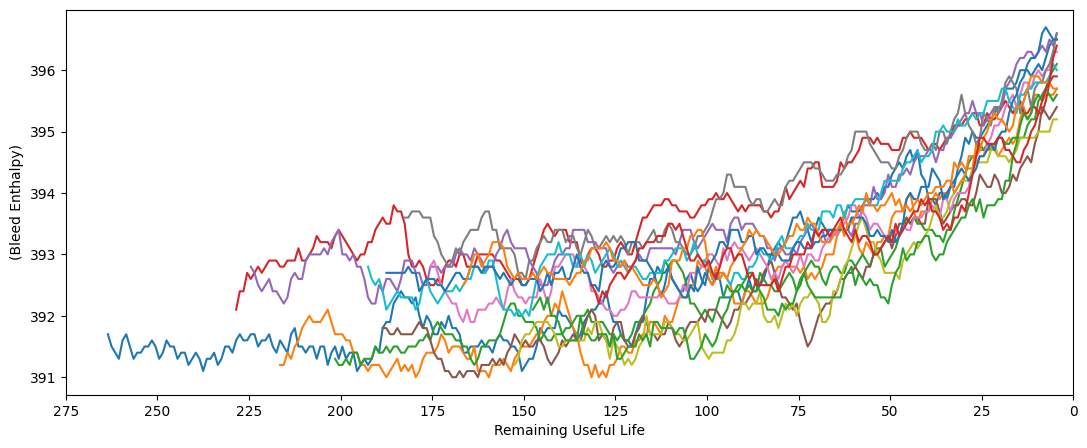

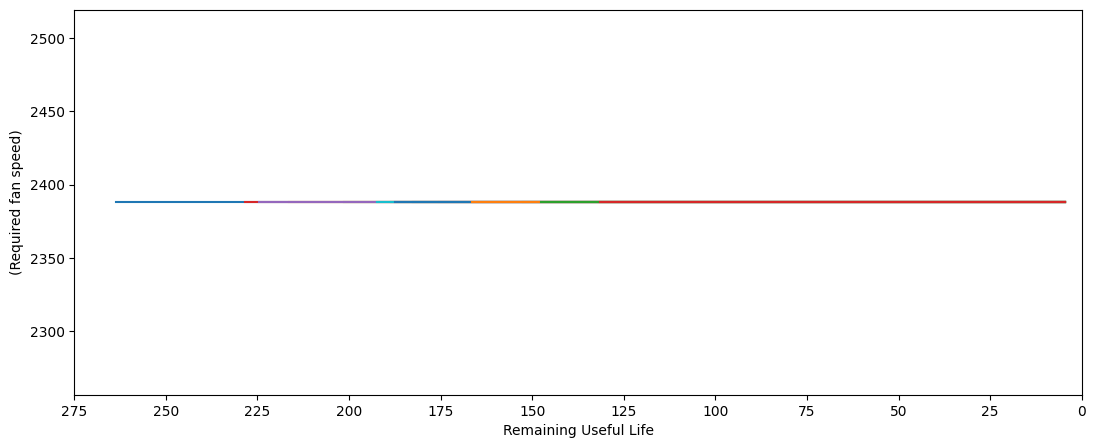

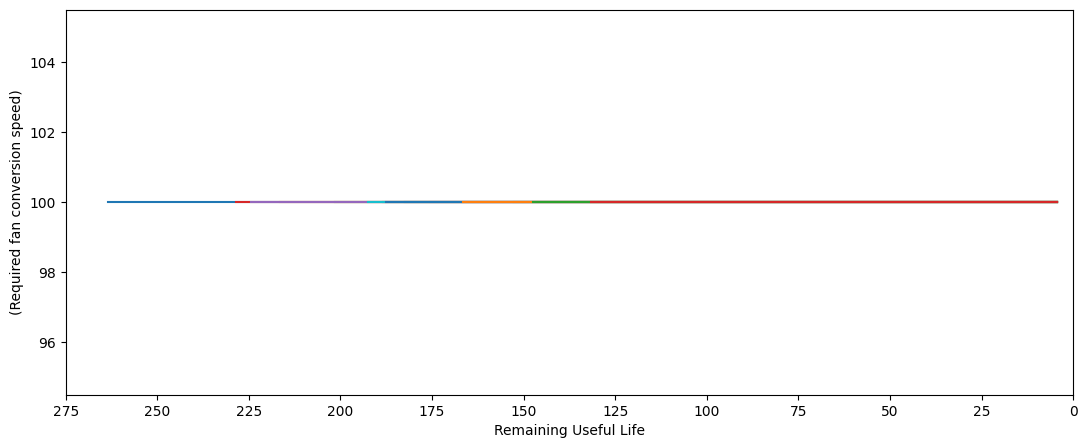

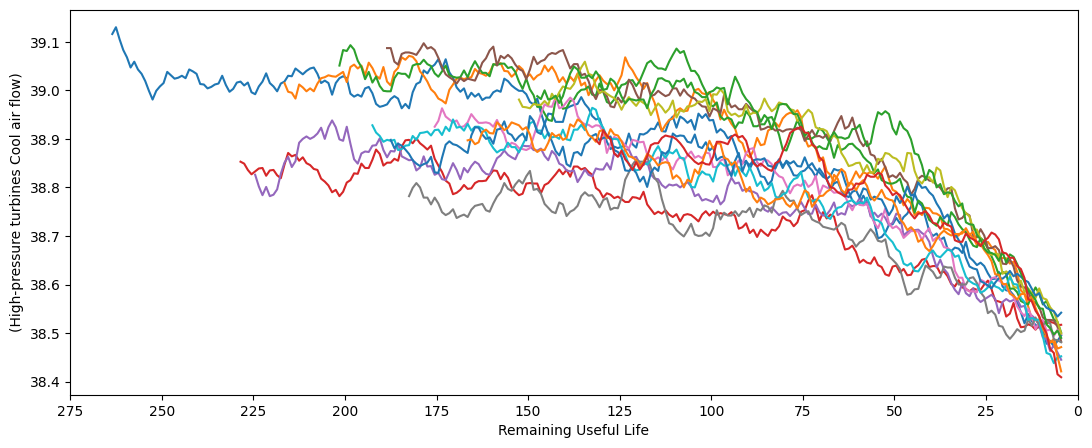

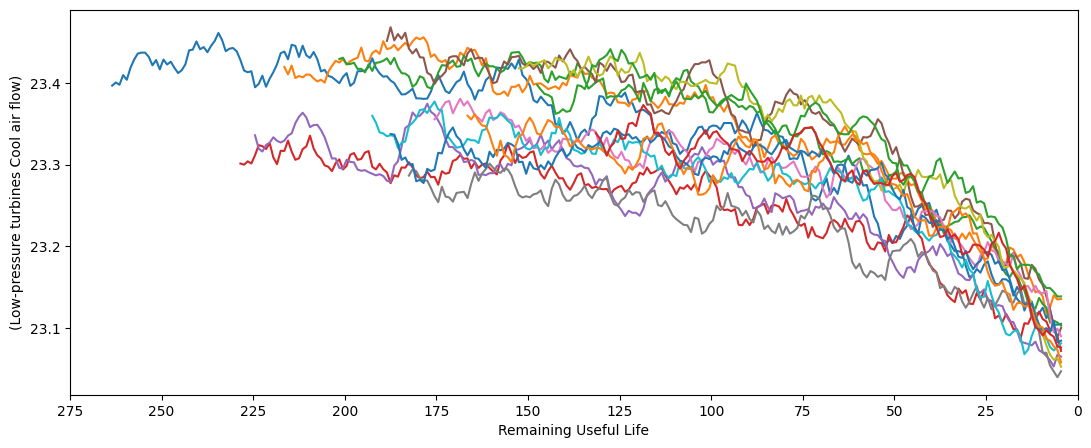

In [17]:
for i in range(1,22):
    try:
        plot_signal(train, Sensor_dictionary,'s_'+str(i))
    except:
        pass

In [18]:
train.loc[:,'s_1':].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
s_1,14130.0,518.670000,0.000000e+00,518.6700,518.6700,518.67000,518.670000,518.6700
s_2,14130.0,642.679557,5.023198e-01,641.2100,642.3200,642.64000,643.010000,644.5300
s_3,14130.0,1590.525633,6.147556e+00,1571.0400,1586.2400,1590.10000,1594.400000,1614.9300
s_4,14130.0,1408.863436,8.996052e+00,1386.4300,1402.2900,1407.94000,1414.510000,1441.4900
s_5,14130.0,14.620000,3.552839e-15,14.6200,14.6200,14.62000,14.620000,14.6200
s_6,14130.0,21.609793,1.422661e-03,21.6000,21.6100,21.61000,21.610000,21.6100
s_7,14130.0,553.378678,8.892235e-01,549.8500,552.8100,553.45000,554.030000,556.0600
s_8,14130.0,2388.094212,7.082073e-02,2387.9000,2388.0400,2388.09000,2388.140000,2388.5600
s_9,14130.0,9066.736406,2.302779e+01,9021.7300,9054.0900,9061.52000,9070.770000,9244.5900
s_10,14130.0,1.300000,2.220525e-16,1.3000,1.3000,1.30000,1.300000,1.3000


MinMax scaler function : Transform features by scaling each feature to a given range.

This estimater scales and translates each feature individually such that it is in the given range on the training set

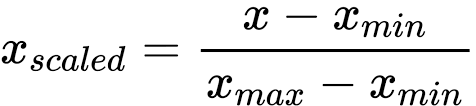

Dropping unnecessary features (labels and settings)

Scaling the data (Min-Max scaler)

In [19]:
def min_max_scaling(column):
    min_value = column.min()
    max_value = column.max()
    scaled_column = (column - min_value) / (max_value - min_value)

    # NaN 값을 0으로 바꿔줌
    scaled_column = scaled_column.fillna(0)

    return scaled_column

In [20]:
columns_to_scale = ['s_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 's_17', 's_18', 's_19', 's_20', 's_21']
train[columns_to_scale] = train[columns_to_scale].apply(min_max_scaling, axis=0)
valid[columns_to_scale] = valid[columns_to_scale].apply(min_max_scaling, axis=0)
full_data[columns_to_scale] = full_data[columns_to_scale].apply(min_max_scaling, axis=0)

Test code

In [21]:
print(train)
print(valid)
print(full_data)

       unit_number  time_cycles  setting_1  setting_2  setting_3  s_1  \
0                1            1    -0.0007    -0.0004      100.0  0.0   
1                1            2     0.0019    -0.0003      100.0  0.0   
2                1            3    -0.0043     0.0003      100.0  0.0   
3                1            4     0.0007     0.0000      100.0  0.0   
4                1            5    -0.0019    -0.0002      100.0  0.0   
...            ...          ...        ...        ...        ...  ...   
14125           70          133    -0.0015    -0.0001      100.0  0.0   
14126           70          134    -0.0012    -0.0004      100.0  0.0   
14127           70          135     0.0004     0.0003      100.0  0.0   
14128           70          136    -0.0044     0.0000      100.0  0.0   
14129           70          137     0.0014    -0.0000      100.0  0.0   

            s_2       s_3       s_4  s_5  ...      s_13      s_14      s_15  \
0      0.183735  0.425154  0.257356  0.0  ..

# Model Implementation

**Linear regression**

# **Loss function Tuning**

**1. Original MSE**

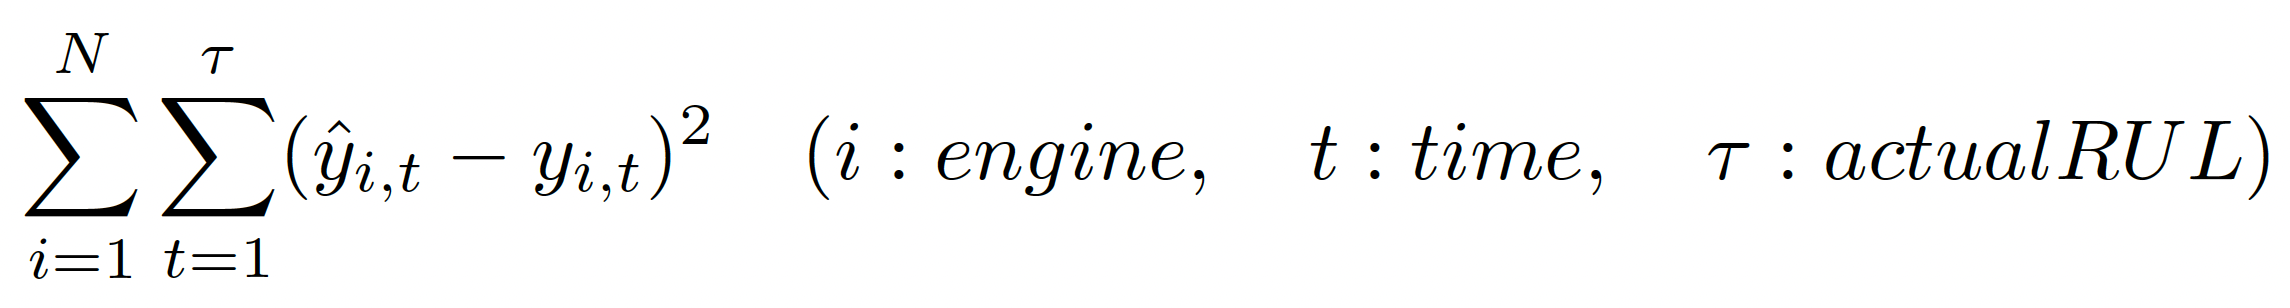

In [22]:
"""
# 1. Original Linear Regression (모든 데이터 사용)
lr1 = LinearRegression()

lr1.fit(X_train_1_s, y_train_clip) #Fitting

y_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data

y_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data

y_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data

print(lr1.coef_)
"""

'\n# 1. Original Linear Regression (모든 데이터 사용)\nlr1 = LinearRegression()\n\nlr1.fit(X_train_1_s, y_train_clip) #Fitting\n\ny_lr_train_1 = lr1.predict(X_train_1_s) #Prediction on train data\n\ny_lr_valid_1 = lr1.predict(X_valid_1_s) #Prediction on validation data\n\ny_lr_full_1 = lr1.predict(X_full_1_s) #Prediction on full data\n\nprint(lr1.coef_)\n'

**2. Crucial moments Loss function**

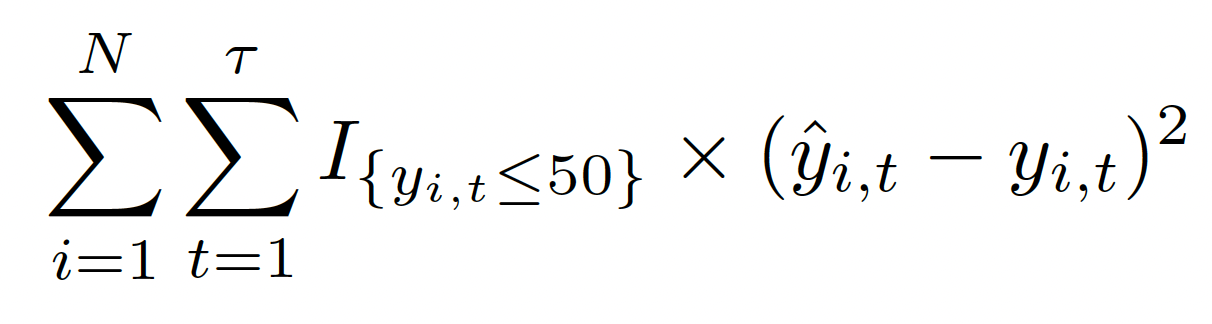

In [23]:
"""
# 2. Crucial moments loss function - Linear Regression

# Filter and save only data that is less than 50.
filtered_data = X_train_1_s[y_train_clip <= 50]
filtered_labels = y_train_clip[y_train_clip <= 50]

lr2 = LinearRegression()

lr2.fit(filtered_data, filtered_labels) #Fitting

y_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data
evaluate(y_train_clip, y_lr_train_2, label='train')

y_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_2, label='valid')

y_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_2, label='full data')

print(lr2.coef_)
"""

"\n# 2. Crucial moments loss function - Linear Regression\n\n# Filter and save only data that is less than 50.\nfiltered_data = X_train_1_s[y_train_clip <= 50]\nfiltered_labels = y_train_clip[y_train_clip <= 50]\n\nlr2 = LinearRegression()\n\nlr2.fit(filtered_data, filtered_labels) #Fitting\n\ny_lr_train_2 = lr2.predict(X_train_1_s) #Prediction on train data\nevaluate(y_train_clip, y_lr_train_2, label='train')\n\ny_lr_valid_2 = lr2.predict(X_valid_1_s) #Prediction on validation data\nevaluate(y_valid, y_lr_valid_2, label='valid')\n\ny_lr_full_2 = lr2.predict(X_full_1_s) #Prediction on full data\nevaluate(y_full, y_lr_full_2, label='full data')\n\nprint(lr2.coef_)\n"

**3. TD Style Loss function (ridge regression)**

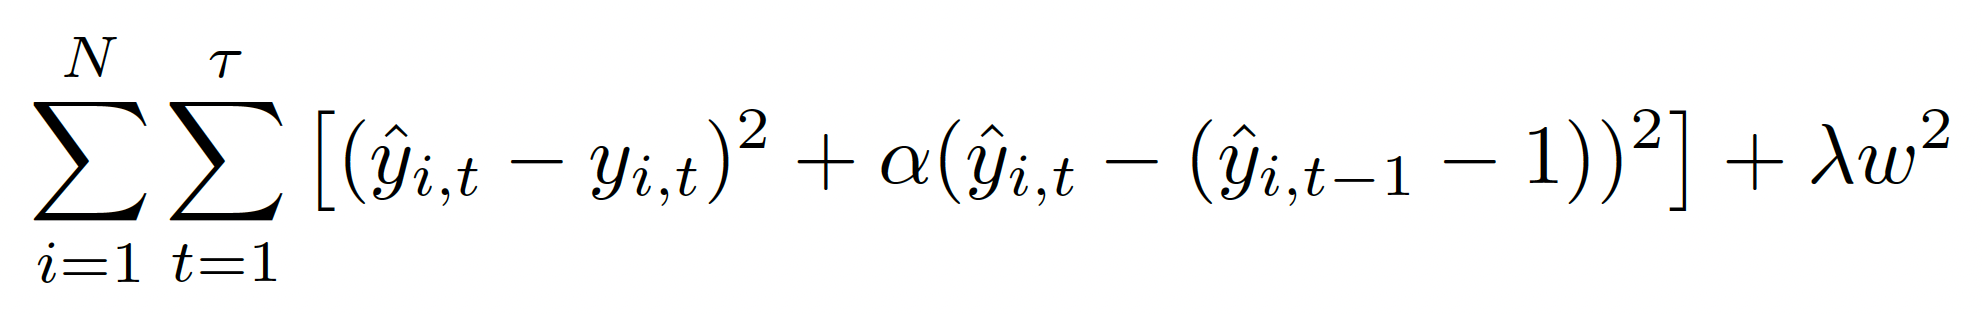

In [24]:
"""
# Multi var linear regression

class Linear_Regression_TD() :
  def __init__( self, alpha=0, lambda_ridge=0 ) :
    self.alpha = alpha
    self.lambda_ridge = lambda_ridge  # Ridge regression

  def fit(self, X, Y, alpha, lambd) :
    self.l, self.p = X.shape
    self.alpha = alpha
    self.lambda_ridge = lambd
    # weight initializer
    self.p = (self.p + 1)         # add constant term.

    self.add_X = np.ones(self.l)
    self.X = np.c_[self.add_X, X]

    self.array_Y = np.array(Y[0:].to_numpy())
    self.array_Y.reshape( self.l, 1 )
    self.Y = self.array_Y
    self.W = np.zeros( self.p ) # W : 0 (b is included)

    self.identity = np.identity( n = self.p ) # Ridge regression
    self.lambda_identity = self.lambda_ridge * self.identity   # lambda * I

    # 각각의 행렬 연산
    X_T_X = (self.X.T) @ (self.X)          # X^(T)X
    X_diff_T_X_diff_sum = np.zeros( [self.p, self.p] )

    for i in range(1, self.l):
      X_diff_T_X_diff = (( self.X[i, :] - self.X[i - 1, :] ).reshape(self.p, 1)) @ (( self.X[i, :] - self.X[i - 1, :] ).reshape(1, self.p))
      X_diff_T_X_diff_sum += X_diff_T_X_diff


    X_T_Y = (self.X.T) @ (self.Y)
    X_T_Y = X_T_Y.reshape( self.p, 1 )
    X_diff_T_sum = np.zeros( [self.p, 1] )

    for i in range(1, self.l):
      X_diff_T = (( self.X[i, :] - self.X[i - 1, :] ).reshape( self.p, 1 ))
      X_diff_T_sum += X_diff_T

    self.W = np.linalg.inv(X_T_X + (self.alpha * X_diff_T_X_diff_sum) + self.lambda_identity) @ (X_T_Y - self.alpha * X_diff_T_sum)

    print(self.W)
    print(self.W.shape)

# X를 입력 받으면 첫 열에 1의 값을 갖는 열을 추가해서 계산해야함. (입력으로 들어오는 X는 (n, 21)이니 (n, 22)로 바꿔줘야 함)
  def predict( self, X) :
    l_X, p_X = X.shape
    p_X = p_X + 1
    add_col = np.ones(l_X)

    X = np.c_[add_col, X]

    return X.dot( self.W )
"""

'\n# Multi var linear regression\n\nclass Linear_Regression_TD() :\n  def __init__( self, alpha=0, lambda_ridge=0 ) :\n    self.alpha = alpha\n    self.lambda_ridge = lambda_ridge  # Ridge regression\n\n  def fit(self, X, Y, alpha, lambd) :\n    self.l, self.p = X.shape\n    self.alpha = alpha\n    self.lambda_ridge = lambd\n    # weight initializer\n    self.p = (self.p + 1)         # add constant term.\n\n    self.add_X = np.ones(self.l)\n    self.X = np.c_[self.add_X, X]\n\n    self.array_Y = np.array(Y[0:].to_numpy())\n    self.array_Y.reshape( self.l, 1 )\n    self.Y = self.array_Y\n    self.W = np.zeros( self.p ) # W : 0 (b is included)\n\n    self.identity = np.identity( n = self.p ) # Ridge regression\n    self.lambda_identity = self.lambda_ridge * self.identity   # lambda * I\n\n    # 각각의 행렬 연산\n    X_T_X = (self.X.T) @ (self.X)          # X^(T)X\n    X_diff_T_X_diff_sum = np.zeros( [self.p, self.p] )\n\n    for i in range(1, self.l):\n      X_diff_T_X_diff = (( self.X[i, :] -

In [25]:
"""
lr3 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting

y_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data

y_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data

y_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data
"""

'\nlr3 = Linear_Regression_TD()\n\n# fit(X, Y, alpha, lambda)        # lambda = 10\nlr3.fit(X_train_1_s, y_train_clip, 0.5, 10) #Fitting\n\ny_lr_train_3 = lr3.predict(X_train_1_s) #Prediction on train data\n\ny_lr_valid_3 = lr3.predict(X_valid_1_s) #Prediction on validation data\n\ny_lr_full_3 = lr3.predict(X_full_1_s) #Prediction on full data\n'

**4. TD Style Loss function + Crucial moments (ridge regression)**

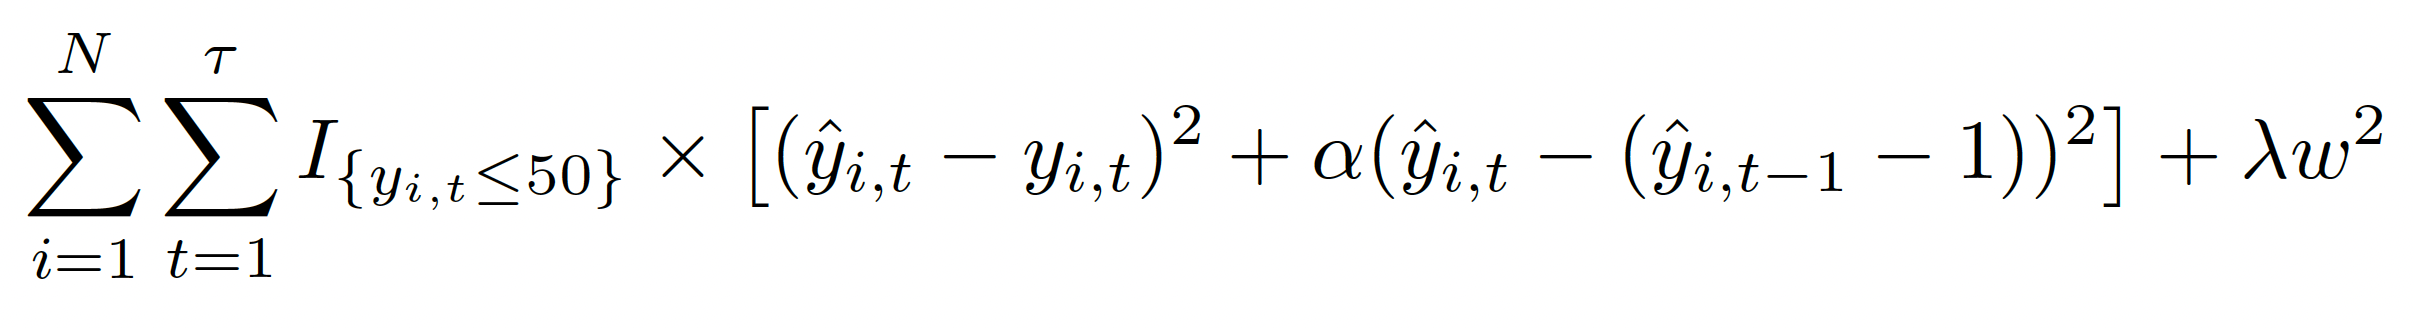

In [26]:
"""
filtered_data_2 = X_train_1_s[y_train_clip <= 50]
filtered_labels_2 = y_train_clip[y_train_clip <= 50]

lr4 = Linear_Regression_TD()

# fit(X, Y, alpha, lambda)        # lambda = 10
lr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting

y_lr_train_4 = lr4.predict(X_train_1_s)
evaluate(y_train_clip, y_lr_train_4, label='train')

y_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data
evaluate(y_valid, y_lr_valid_4, label='valid')

y_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data
evaluate(y_full, y_lr_full_4, label='full data')
"""

"\nfiltered_data_2 = X_train_1_s[y_train_clip <= 50]\nfiltered_labels_2 = y_train_clip[y_train_clip <= 50]\n\nlr4 = Linear_Regression_TD()\n\n# fit(X, Y, alpha, lambda)        # lambda = 10\nlr4.fit(filtered_data_2, filtered_labels_2, 0.5, 10) #Fitting\n\ny_lr_train_4 = lr4.predict(X_train_1_s)\nevaluate(y_train_clip, y_lr_train_4, label='train')\n\ny_lr_valid_4 = lr4.predict(X_valid_1_s) #Prediction on validation data\nevaluate(y_valid, y_lr_valid_4, label='valid')\n\ny_lr_full_4 = lr4.predict(X_full_1_s) #Prediction on full data\nevaluate(y_full, y_lr_full_4, label='full data')\n"

# **Value-based RL**

Min-Max Scale을 마친 데이터에 's_0' column 추가 (1로 초기화)

In [27]:
train.insert(loc=5, column='s_0', value=1)
valid.insert(loc=5, column='s_0', value=1)
full_data.insert(loc=5, column='s_0', value=1)

# Environment (observation probability 추가)

In [28]:
from copy import copy
# epsilon을 지수형태로 바꿔서 해보자. (우선 아래 세팅부터)
gamma = 0.999   # discount factor
alpha = 0.001    # learning rate
initial_epsilon = 0.8      # epsilon-greedy에서 initial epsilon 값.
epsilon_delta = 0.0035     # epsilon 감소량 (실제로 학습시킬 때, Max episode에 맞게 조절하자. linear로 떨어지도록)
min_epsilon = 0         # 최소 epsilon (epsilon greedy algorithm)
max_episodes = 450   # 전체 데이터 셋에 대한 학습 횟수.

# random observation 기능을 위한 변수 선언
observation_probability = 0.3 # 이 값보다 작거나 같으면 관측하고 action 수행 후 q-value 업데이트가 이뤄지도록 설정.
                              # 이 값보다 크면, action은 continue로 고정하고 (replace를 할 기회가 없으니) q-value 업데이트가 이뤄지지 않도록 설정.

In [29]:
environment = train                                # environment는 train dataset.
max_unit_number = environment['unit_number'].max() # 마지막 unit_number를 return. (1~70이라면 70 반환)

# train에서 state들 분리 (s_1, s_2, ... , s_21)
# state set 정의
states = environment[['s_{}'.format(i) for i in range(0, 22)]]

# action 정의
actions = ["continue", "replace"]

# 각 action(continue, relpace)에 대한 weight (Linear Function Approximation; LFA)
# action 각각에 대한 Q-function을 학습 후, 이를 이용해 value가 더 높은 action을 선택하도록 함.
# standard normal distribution에서 initial weight 추출.
weights = {
    "continue": np.random.normal(loc=0, scale=0.5, size=len(states.columns)),
    "replace": np.random.normal(loc=0, scale=0.5, size=len(states.columns))
}
# best weights
best_weights = {
    "continue": np.random.normal(loc=0, scale=0.5, size=len(states.columns)),
    "replace": np.random.normal(loc=0, scale=0.5, size=len(states.columns))
}

**Reward 정의**

In [30]:
# 이 reward를 계산하면 Total cost임. 이 구조로 parameter를 업데이트하면 단위 시간당 cost 구조가 반영이 안됨.
# Parameter update를 할 때는, ( Total reward / time step of each episode )로 하면 반영되지 않을까?
#    -> parameter update가 매 step마다 이뤄지고 있다는 것을 고려해야함. MC가 아니라 TD 방식이므로. 에피소드 끝까지 기다리고 업데이트 하지 않음.

# 위의 방법대로 나눠서 파라메터 업데이트 하는 방식으로 해주면 가능할 것 같음.
# 일단 이건 패스, 구현 마치고 수정하자.
r_continue = 0
r_continue_but_failure = -10000
r_replace = -1000                # 이 cost는 linear regression 실험과 비교하기 위해 1000으로 둠.


def calculateReward(current_index, next_index, action):
    # 'unit_number' 열의 현재 및 다음 행 값 추출
    current_unit_number = environment['unit_number'].iloc[current_index]
    next_unit_number = environment['unit_number'].iloc[next_index]

    if action == 'continue':
        # 다음 'unit_number'가 바뀌지 않으면 0 (next state가 failure가 아님)
        if current_unit_number == next_unit_number:
          return r_continue
        # 다음 'unit_number'가 바뀌면 -10,000 (next state가 failure; replace 실패에 해당)
        else:
          return r_continue_but_failure
    elif action == 'replace':
      # 'Replace' 액션을 취한 경우, 다음 'unit_number'로 교체됨
      # 이 경우, 다음 'unit_number'가 1로 초기화되므로 -1,000의 보상을 줄 수 있음
      return r_replace

In [31]:
def nextStateIndex(action, current_index):
  # action에 따라 next state가 달라짐.
  if action == 'continue':
    return current_index + 1
  else:
    # replace인 경우 next_state는 다음 엔진(unit_number)의 첫번째 행.
    current_unit_number = environment['unit_number'].iloc[current_index]
    next_unit_initial_index = environment[environment['unit_number'] == current_unit_number].index[-1] + 1
    return next_unit_initial_index

In [32]:
def stateMinIndex(current_index):
  current_unit_number = environment['unit_number'].iloc[550]
  return environment[environment['unit_number'] == (current_unit_number)].index[0]

**Optimal Stopping Problem을 위한 Value-based RL**

의사결정을 10번 중 한번만 한다면, 그 나머지 9번에 대한 의사결정은 어떻게 처리해야 할까?
이떄는 q-value에 대한 업데이트 없이 그냥 마지막 결정이 continue라면 다음 9번의 action은 continue로,
마지막 결정이 replace라면 replace 후, 다음의 9번의 action은 continue로 가도록 해볼까? -> ok.

그럼, epsilon의 확률로 exploration (하나의 engine에 대한 replace time을 사전에 정해두고 실험) 하는 것은 그대로 두고,

1-epsilon의 확률일 때, greedy action을 수정해야 하는데.. 여기에서만 action에 따른 이후 9번의 action은 continue로 하는 것이 맞을까? -> 의사결정을 할 기회가 없으니, replace 하지 않았다면 기계는자동 continue로 간주할 수 있으니 이게 맞음!

이 때, 관측되지 않은 경우의 continue는 q-value를 업데이트 하면 안됨.

만약 10% 확률로 관측하고 의사결정을 내리는 코드로 바꾼다면, performance는 몇번의 관측 뒤에 멈추는지 보면 됨.

episode : 1, replace failure : 9, Average Reward : -73.61660079051383, loss : 148853.92961917276, Average NoObs : 7.314285714285714
episode : 2, replace failure : 13, Average Reward : -48.890063424947144, loss : 183977.8048917568, Average NoObs : 13.271428571428572
episode : 3, replace failure : 7, Average Reward : -41.13029827315542, loss : 129631.04136807076, Average NoObs : 11.257142857142858
episode : 4, replace failure : 13, Average Reward : -45.8601883986118, loss : 182210.3329944374, Average NoObs : 15.614285714285714
episode : 5, replace failure : 11, Average Reward : -53.54280218018596, loss : 164396.26889444373, Average NoObs : 10.414285714285715
episode : 6, replace failure : 11, Average Reward : -49.89542874215716, loss : 162942.58217510465, Average NoObs : 12.8
episode : 7, replace failure : 11, Average Reward : -70.16806722689076, loss : 163516.49073804464, Average NoObs : 8.8
episode : 8, replace failure : 14, Average Reward : -60.47381546134663, loss : 189977.2733635424

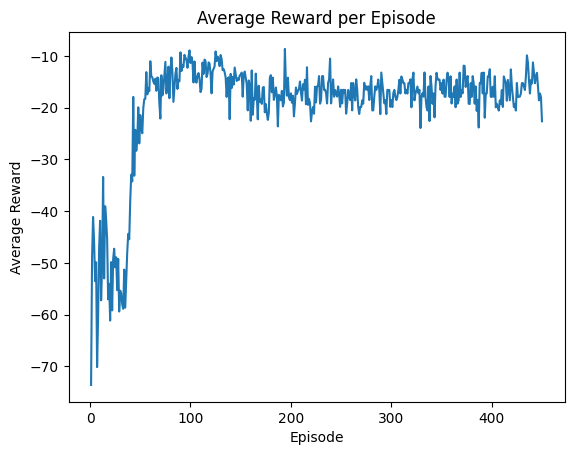

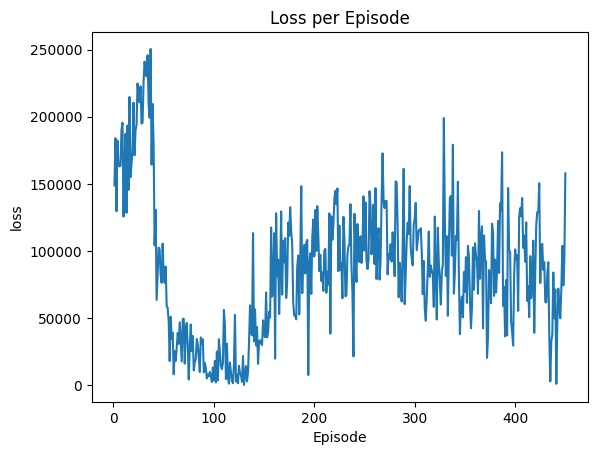

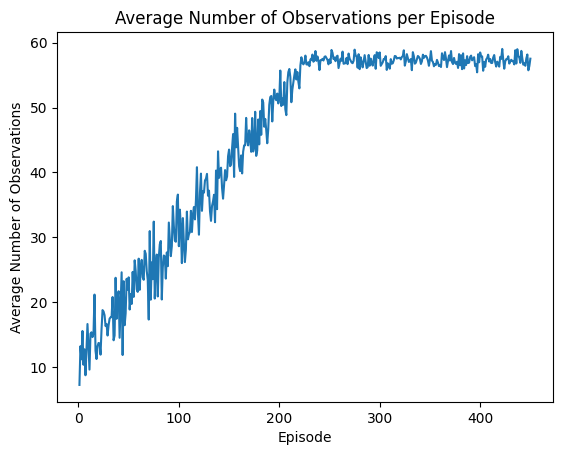

In [33]:
# For optimal stopping (random episode)
# max_episodes 만큼 반복.
average_rewards = []
training_loss = []
average_number_of_observations = []  # 엔진당 평균 관측 횟수를 저장.
best_average_reward = -10000

# parameter of random episode
size_of_t_replace = environment['unit_number'].max() - 1 # unit98이 마지막이면, unit99가 다음
min_t_replace = 1    # stopping time을 결정할 때 최소값에 해당하는 parameter
max_t_replace = 200  # stopping time을 결정할 때 최대값에 해당되는 parameter (즉, min_t_replace < random integer < max_t_replace 사이에서 랜덤한 정수를 뽑음)

for episode in range(max_episodes):

    replace_failure = 0  # each episode 마다 초기화. 누적시킬 필요는 없음.
    state_index = 0      # state index -> index pointer로 취급하자. (episode 마다 초기화)
    total_reward = 0
    num_of_step = 0
    loss_episode = 0
    number_of_observation = 0

    # cum_total_reward <- 이게 필요한가? reward는 각 episode별로 알면 끝인가? 아마 맞는듯. (나중에 다시 체크)

    # 이 맨 밖의 for문이 이상함. 이거 해결하자. (지금은 아래의 학습 과정이 이 for문만큼 실행됨.)
    # 하나의 episode는 전체 엔진을 모두 사용할 때까지!
    # 지금 코드는 episode 내의 각 engine 별로 exploration 여부를 epsilon으로 결정함.
    for unit_num in range(max_unit_number):  # unit num : 0, .... , (max_unit_number - 1)
        state = states.iloc[state_index].values

       # decay epsilon (linear)
        epsilon = max(min_epsilon, initial_epsilon - episode * epsilon_delta) # epsilon decay는 episode에 따라 감소해야함.

        # random episode를 위한 조건 분기
        # random episode까지 10% 확률로 관측하고 업데이트하게 만들면 배우는 것이 너무 없으니, 그대로 둠.
        if np.random.rand() < epsilon:
          # unit 수 만큼, uniform distribution에서 t_replace을 뽑기 (시작부터 에피소드 내의 모든 t_replace 결정)
          # 마지막 unit 이후의 action도 알아야 하므로, greedy-Action을 하는 반복문보다 unit을 하나 더 앞까지 보자.
          t_replace = [random.randint(min_t_replace, max_t_replace) for _ in range(size_of_t_replace)]

          # out of bound 문제를 막기 위해 '최대 unit number - 1'의 끝에 도달하면 멈추게 함. 데이터에 마지막 더미 row를 추가해서, 원본 데이터를 모두 활용할 수 있도록 수정하자.
          while (state_index < environment[environment['unit_number'] == (environment['unit_number'].max() - 2)].index[-1] + 1) and environment['unit_number'].iloc[state_index] == (unit_num + 1):
            current_state = state

            # t_replace[unit_number - 1] 이하면 continue. stateMinIndex func을 통해 state_index가 해당되는 unit의 최소 index를 가져옴.
            if state_index < ( stateMinIndex(state_index) + t_replace[environment['unit_number'].iloc[state_index] - 1] ):
              chosen_action = 'continue'
            else:
              chosen_action = 'replace'

            next_state_index = nextStateIndex(chosen_action, state_index)
            next_state = states.iloc[next_state_index].values # S_{t+1}

            current_reward = calculateReward(state_index, next_state_index, chosen_action)

            # count 'replace failure'
            if current_reward == (-10000):
              replace_failure += 1

            # next action
            if next_state_index < stateMinIndex(next_state_index) + t_replace[environment['unit_number'].iloc[next_state_index] - 1]:
              next_chosen_action = 'continue'
            else:
              next_chosen_action = 'replace'

            # update q-value (Linear Function Approximation)
            next_state_q = np.dot(weights[next_chosen_action], next_state)    # A' ~ random generated episode
            current_state_q = np.dot(weights[chosen_action], current_state)   # A  ~ random generated episode

            # TD target, weight
            TD_target = current_reward + gamma * next_state_q
            delta_w = alpha * (TD_target - current_state_q) * current_state

            weights[chosen_action] = weights[chosen_action] + delta_w

            # 총 리워드 업데이트
            total_reward += current_reward
            loss_episode += TD_target - current_state_q

            # 다음 상태로 이동
            state_index = next_state_index
            state = states.iloc[state_index].values
            num_of_step += 1

        # random episode가 아닌 경우, greedy action 수행.
        # 이 부분을 random observation으로 수정하자.
        else:
          while (state_index < environment[environment['unit_number'] == (environment['unit_number'].max() - 2)].index[-1] + 1) and environment['unit_number'].iloc[state_index] == (unit_num + 1):
            current_state = state
            random_observation = np.random.rand()

            if random_observation < observation_probability:
              chosen_action = max(actions, key=lambda a: np.dot(weights[a], current_state)) # greedy action
              number_of_observation += 1

            else:
              chosen_action = 'continue'                 # observation x -> continue (관측했을때만 replace 가능)

            next_state_index = nextStateIndex(chosen_action, state_index)
            next_state = states.iloc[next_state_index].values # S_{t+1}

            current_reward = calculateReward(state_index, next_state_index, chosen_action)

            # count 'replace failure'
            if current_reward == (-10000):
                replace_failure += 1

            # update q-value (Linear Function Approximation)
            next_state_q = max([np.dot(weights[a], next_state) for a in actions])  # A' ~ greedy action
            current_state_q = np.dot(weights[chosen_action], current_state)        # A  ~ greedy action

            TD_target = current_reward + gamma * next_state_q
            delta_w = alpha * (TD_target - current_state_q) * current_state


            # 관측되었을때만 weight을 업데이트. 즉 10% 확률로 관측하고, 그때만 weight의 업데이트가 이뤄짐.
            if random_observation < observation_probability:
              weights[chosen_action] = weights[chosen_action] + delta_w


            # 총 리워드 업데이트
            total_reward += current_reward

            # episode 내에서의 loss 누적
            loss_episode += TD_target - current_state_q

            # 다음 상태로 이동
            state_index = next_state_index
            state = states.iloc[state_index].values
            num_of_step += 1


    # episode 학습 결과 출력
    average_reward = total_reward / num_of_step
    average_number_of_observation = number_of_observation / max_unit_number

    # best weight 저장
    if average_reward > best_average_reward:
      best_average_reward = copy(average_reward)
      best_weights = copy(weights)

    average_rewards.append(average_reward)
    training_loss.append(np.abs(loss_episode))
    average_number_of_observations.append(average_number_of_observation)
    print(f"episode : {episode + 1}, replace failure : {replace_failure}, Average Reward : {average_reward}, loss : {np.abs(loss_episode)}, Average NoObs : {average_number_of_observation}")


# episode에 따른 average reward
plt.plot(range(1, max_episodes + 1), average_rewards)
plt.xlabel('Episode')
plt.ylabel('Average Reward')
plt.title('Average Reward per Episode')
plt.show()

# loss plot
plt.plot(range(1, max_episodes + 1), training_loss)
plt.xlabel('Episode')
plt.ylabel('loss')
plt.title('Loss per Episode')
plt.show()

# episode에 따른 number of observation
plt.plot(range(1, max_episodes + 1), average_number_of_observations)
plt.xlabel('Episode')
plt.ylabel('Average Number of Observations')
plt.title('Average Number of Observations per Episode')
plt.show()

off-policy TD(0) : Q-learning

R_t version (원래는 Target이 R_{t+1})

In [34]:
print(weights['continue'])

[-5.10481914e+03 -3.73659091e-01 -1.68185823e+02 -1.12477556e+02
 -3.51263654e+02 -6.40745938e-01 -2.58828560e+01  6.11782534e+01
 -6.75650214e+02 -7.26298794e+02  3.76221725e-01 -5.08985921e+02
  5.08175835e+01 -7.10337364e+02 -8.37478285e+02 -2.60122989e+02
 -1.04737468e+00 -1.99690214e+02 -7.17070331e-01 -1.39114349e-01
  5.92867907e+01  2.02036118e+01]


In [35]:
print(weights['replace'])

[-2.82145439e+03  6.30523464e-01 -1.03387280e+02 -6.26645012e+01
  3.69483649e+02 -1.48869610e-01 -2.53327358e+03 -2.53323407e+03
 -2.93594821e+02  9.02357918e+02  2.84610807e-02  2.70533474e+02
 -2.66612288e+03 -3.31261008e+02  7.85241970e+02 -1.18267037e+02
  2.78843125e-01  5.54595351e+01  1.03343513e-01 -3.22527653e-01
 -2.58056654e+03 -2.71072546e+03]


In [36]:
print(best_weights['continue'])

[-3.57335845e+03 -3.73659091e-01 -2.85492486e+02 -2.84220308e+02
 -5.71424648e+02 -6.40745938e-01 -1.14395337e+02 -3.21414646e+02
 -8.66207626e+02 -9.60525541e+02  3.76221725e-01 -7.99004873e+02
 -3.91432240e+02 -9.32710137e+02 -1.02201475e+03 -4.27832960e+02
 -1.04737468e+00 -3.71036632e+02 -7.17070331e-01 -1.39114349e-01
 -1.66580046e+02 -1.52498076e+02]


In [37]:
print(best_weights['replace'])

[-2.75834727e+03  6.30523464e-01 -7.89090889e+01 -8.35485389e+01
  4.26884755e+02 -1.48869610e-01 -2.48430707e+03 -2.65436069e+03
 -1.17907967e+02  4.75025165e+02  2.84610807e-02  3.67010010e+02
 -2.81339220e+03 -1.65001022e+02  3.26771005e+02 -3.82550503e+01
  2.78843125e-01  3.60853919e+01  1.03343513e-01 -3.22527653e-01
 -2.67586368e+03 -2.79515372e+03]


**학습된 Q로 전체 데이터에 대해 성능 테스트**

In [38]:
# 함수 뒤에 dataset을 입력으로 받아서 train 함수와 동일하게 사용하자.

In [39]:
full_data

,unit_number,time_cycles,setting_1,setting_2,setting_3,s_0,s_1,s_2,s_3,s_4,...,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,RUL
0,1,1,-0.0007,-0.0004,100.0,1,0.0,0.183735,0.406802,0.309757,...,0.205882,0.199608,0.363986,0.0,0.333333,0.0,0.0,0.713178,0.724662,191
1,1,2,0.0019,-0.0003,100.0,1,0.0,0.283133,0.453019,0.352633,...,0.279412,0.162813,0.411312,0.0,0.333333,0.0,0.0,0.666667,0.731014,190
2,1,3,-0.0043,0.0003,100.0,1,0.0,0.343373,0.369523,0.370527,...,0.220588,0.171793,0.357445,0.0,0.166667,0.0,0.0,0.627907,0.621375,189
3,1,4,0.0007,0.0000,100.0,1,0.0,0.343373,0.256159,0.331195,...,0.294118,0.174889,0.166603,0.0,0.333333,0.0,0.0,0.573643,0.662386,188
4,1,5,-0.0019,-0.0002,100.0,1,0.0,0.349398,0.257467,0.404625,...,0.235294,0.174734,0.402078,0.0,0.416667,0.0,0.0,0.589147,0.704502,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,1,0.0,0.686747,0.587312,0.782917,...,0.558824,0.194344,0.656791,0.0,0.750000,0.0,0.0,0.271318,0.109500,4
20627,100,197,-0.0016,-0.0005,100.0,1,0.0,0.701807,0.729453,0.866475,...,0.500000,0.188668,0.727203,0.0,0.583333,0.0,0.0,0.124031,0.366197,3
20628,100,198,0.0004,0.0000,100.0,1,0.0,0.665663,0.684979,0.775321,...,0.529412,0.212148,0.922278,0.0,0.833333,0.0,0.0,0.232558,0.053991,2
20629,100,199,-0.0011,0.0003,100.0,1,0.0,0.608434,0.746021,0.747468,...,0.514706,0.203065,0.823394,0.0,0.583333,0.0,0.0,0.116279,0.234466,1


In [40]:
environment_test = full_data
states_test = environment_test[['s_{}'.format(i) for i in range(0, 22)]]

In [41]:
def calculateRewardTest(current_index, next_index, action):
    # 'unit_number' 열의 현재 및 다음 행 값 추출
    current_unit_number = environment_test['unit_number'].iloc[current_index]
    next_unit_number = environment_test['unit_number'].iloc[next_index]

    if action == 'continue':
        # 다음 'unit_number'가 바뀌지 않으면 0 (next state가 failure가 아님)
        if current_unit_number == next_unit_number:
          return r_continue
        # 다음 'unit_number'가 바뀌면 -10,000 (next state가 failure; replace 실패에 해당)
        else:
          return r_continue_but_failure
    elif action == 'replace':
      # 'Replace' 액션을 취한 경우, 다음 'unit_number'로 교체됨
      # 이 경우, 다음 'unit_number'가 1로 초기화되므로 -1,000의 보상을 줄 수 있음
      return r_replace

In [42]:
def nextStateIndexTest(action, current_index):
  # action에 따라 next state가 달라짐.
  if action == 'continue':
    return current_index + 1
  else:
    # replace인 경우 next_state는 다음 엔진(unit_number)의 첫번째 행.
    current_unit_number = environment_test['unit_number'].iloc[current_index]
    next_unit_initial_index = environment_test[environment_test['unit_number'] == current_unit_number].index[-1] + 1
    return next_unit_initial_index

학습된 weight으로 모든 time-step에서 의사결정을 내릴 수 있을 때의 성능.

In [43]:
max_unit_number = environment_test['unit_number'].max() # 마지막 unit_number를 return. (1~70이라면 70 반환)
replace_failure = 0
state_index = 0      # state index -> index pointer로 취급.
total_reward = 0
num_of_step = 0
average_rewards = 0
average_usage_time = 0
number_of_observation = 0

for unit_num in range(max_unit_number):  # unit num : 0, .... , (max_unit_number - 1)
    state = states_test.iloc[state_index].values

    # out of bound 문제를 막기 위해 '최대 unit number - 1'의 끝에 도달하면 멈추게 함. 데이터에 마지막 더미 row를 추가해서, 원본 데이터를 모두 활용할 수 있도록 수정하자.
    while (state_index < environment_test[environment_test['unit_number'] == (environment_test['unit_number'].max() - 2)].index[-1] + 1) and environment_test['unit_number'].iloc[state_index] == (unit_num + 1):
        current_state = state

        chosen_action = max(actions, key=lambda a: np.dot(best_weights[a], current_state))

        next_state_index = nextStateIndexTest(chosen_action, state_index)
        next_state = states_test.iloc[next_state_index].values # S_{t+1}
        current_reward = calculateRewardTest(state_index, next_state_index, chosen_action)

        # count 'replace failure'
        if current_reward == (-10000):
            replace_failure += 1
            #print(replace_failure)

        # 총 리워드 업데이트
        total_reward += current_reward

        # 다음 상태로 이동
        state_index = next_state_index
        state = states_test.iloc[state_index].values
        num_of_step += 1

# episode 학습 결과 출력
average_reward = total_reward / num_of_step
average_usage_time = num_of_step / (environment_test['unit_number'].max() - 2)
print(f"Number of Engine : {environment_test['unit_number'].max() - 2}, Average Reward : {average_reward}, replace failure : {replace_failure}, average usage time : {average_usage_time}")
#print(np.dot(weights['continue'], states_test.iloc[state_index].values))
#print(np.dot(weights['replace'], states_test.iloc[state_index].values))




Number of Engine : 98, Average Reward : -5.005362888809438, replace failure : 0, average usage time : 199.78571428571428


학습된 weight으로 10% 확률로 의사결정을 내릴 수 있을 때의 성능 (나머지 90%는 continue)

In [44]:
max_unit_number = environment_test['unit_number'].max() # 마지막 unit_number를 return. (1~70이라면 70 반환)
replace_failure = 0
state_index = 0      # state index -> index pointer로 취급.
total_reward = 0
num_of_step = 0
average_rewards = 0
average_usage_time = 0
number_of_observation = 0

for unit_num in range(max_unit_number):  # unit num : 0, .... , (max_unit_number - 1)
    state = states_test.iloc[state_index].values

    # out of bound 문제를 막기 위해 '최대 unit number - 1'의 끝에 도달하면 멈추게 함. 데이터에 마지막 더미 row를 추가해서, 원본 데이터를 모두 활용할 수 있도록 수정하자.
    while (state_index < environment_test[environment_test['unit_number'] == (environment_test['unit_number'].max() - 2)].index[-1] + 1) and environment_test['unit_number'].iloc[state_index] == (unit_num + 1):
        current_state = state
        random_observation = np.random.rand()

        if random_observation < observation_probability:
          chosen_action = max(actions, key=lambda a: np.dot(best_weights[a], current_state)) # greedy action
          number_of_observation += 1
        else:
          chosen_action = 'continue'

        next_state_index = nextStateIndexTest(chosen_action, state_index)
        next_state = states_test.iloc[next_state_index].values # S_{t+1}
        current_reward = calculateRewardTest(state_index, next_state_index, chosen_action)

        # count 'replace failure'
        if current_reward == (-10000):
            replace_failure += 1

        # 총 리워드 업데이트
        total_reward += current_reward

        # 다음 상태로 이동
        state_index = next_state_index
        state = states_test.iloc[state_index].values
        num_of_step += 1

# episode 학습 결과 출력
average_reward = total_reward / num_of_step
average_usage_time = num_of_step / (environment_test['unit_number'].max() - 2)
average_number_of_observation = number_of_observation / max_unit_number

print(f"Number of Engine : {environment_test['unit_number'].max() - 2}, Average Reward : {average_reward}, replace failure : {replace_failure}, average usage time : {average_usage_time}, Average NoObs : {average_number_of_observation}")



Number of Engine : 98, Average Reward : -14.896079714156308, replace failure : 22, average usage time : 202.76530612244898, Average NoObs : 59.5


# Q-value를 remaining useful life (RUL) prediction으로 convert

Best weights 가져오기

In [45]:
save_weights = copy(best_weights)
print(save_weights)

{'continue': array([-3.57335845e+03, -3.73659091e-01, -2.85492486e+02, -2.84220308e+02,
       -5.71424648e+02, -6.40745938e-01, -1.14395337e+02, -3.21414646e+02,
       -8.66207626e+02, -9.60525541e+02,  3.76221725e-01, -7.99004873e+02,
       -3.91432240e+02, -9.32710137e+02, -1.02201475e+03, -4.27832960e+02,
       -1.04737468e+00, -3.71036632e+02, -7.17070331e-01, -1.39114349e-01,
       -1.66580046e+02, -1.52498076e+02]), 'replace': array([-2.75834727e+03,  6.30523464e-01, -7.89090889e+01, -8.35485389e+01,
        4.26884755e+02, -1.48869610e-01, -2.48430707e+03, -2.65436069e+03,
       -1.17907967e+02,  4.75025165e+02,  2.84610807e-02,  3.67010010e+02,
       -2.81339220e+03, -1.65001022e+02,  3.26771005e+02, -3.82550503e+01,
        2.78843125e-01,  3.60853919e+01,  1.03343513e-01, -3.22527653e-01,
       -2.67586368e+03, -2.79515372e+03])}


In [46]:
"""
save_weights["continue"] = [-4.30245224e+03, -3.73659091e-01, -1.73384550e+02, -1.59458043e+02,
                            -3.22003504e+02, -6.40745938e-01, -4.98493298e+01, -8.78628713e+00,
                            -6.42078986e+02, -6.36564751e+02, 3.76221725e-01, -5.21961158e+02,
                            -1.26704656e+01, -6.69433841e+02, -7.12489527e+02, -2.74123590e+02,
                            -1.04737468e+00, -2.05690113e+02, -7.17070331e-01, -1.39114349e-01,
                            4.47449025e+00, -4.73254967e-01]
save_weights["replace"] =  [-1.94540964e+03, 6.30523464e-01, -5.65142798e+02, -5.83873883e+02,
                            -5.16732877e+02, -1.48869610e-01, -7.58774405e+02, -9.33233402e+02,
                            -4.94082551e+02, -2.11609921e+02, 2.84610807e-02, -5.83031562e+02,
                            -9.69583248e+02, -5.50524332e+02, -2.31456750e+02, -5.99695370e+02,
                            2.78843125e-01, -5.83557102e+02, 1.03343513e-01, -3.22527653e-01,
                            -8.24045590e+02, -8.47556863e+02]
"""

'\nsave_weights["continue"] = [-4.30245224e+03, -3.73659091e-01, -1.73384550e+02, -1.59458043e+02,\n                            -3.22003504e+02, -6.40745938e-01, -4.98493298e+01, -8.78628713e+00,\n                            -6.42078986e+02, -6.36564751e+02, 3.76221725e-01, -5.21961158e+02,\n                            -1.26704656e+01, -6.69433841e+02, -7.12489527e+02, -2.74123590e+02,\n                            -1.04737468e+00, -2.05690113e+02, -7.17070331e-01, -1.39114349e-01,\n                            4.47449025e+00, -4.73254967e-01]\nsave_weights["replace"] =  [-1.94540964e+03, 6.30523464e-01, -5.65142798e+02, -5.83873883e+02,\n                            -5.16732877e+02, -1.48869610e-01, -7.58774405e+02, -9.33233402e+02,\n                            -4.94082551e+02, -2.11609921e+02, 2.84610807e-02, -5.83031562e+02,\n                            -9.69583248e+02, -5.50524332e+02, -2.31456750e+02, -5.99695370e+02,\n                            2.78843125e-01, -5.83557102e+02, 1.03

In [47]:
"""
# best weights (by Q-learning best_weights; RL_Toy_Example_25)
save_weights = {
    "continue": np.random.normal(loc=0, scale=0.5, size=len(states.columns)),
    "replace": np.random.normal(loc=0, scale=0.5, size=len(states.columns))
}
save_weights["continue"] = [ 1.21917550e-01, -1.76674057e+03, -1.69654640e+03, -2.12784329e+03,
                            -1.76031172e-01, -5.41407715e+02,  1.71969275e+03, -1.42636484e+03,
                             -9.58899289e+02, 2.25409067e-01, -2.38937267e+03, 1.80436677e+03,
                             -1.32237276e+03, -7.75611348e+02, -1.84484215e+03, 9.07570238e-01,
                             -1.72423314e+03, 5.17978057e-01, -7.17070331e-01, 1.60180476e+03,
                             1.98753523e+03]
save_weights["replace"] = [-6.54156068e-01, -9.31194035e+02, -9.86249665e+02, -8.18887605e+02,
                           7.14963860e-01, -2.55475982e+03, -1.77602288e+03, -6.41691636e+02,
                           -4.08847651e+02, -6.02734107e-01, -7.70459163e+02, -1.85903546e+03,
                           -7.04479461e+02, -4.89540991e+02, -9.74286548e+02, 4.62803201e-01,
                           -1.06291167e+03, 2.78843125e-01, -2.72662147e-01, -1.62420478e+03,
                           -1.72686191e+03]
"""

'\n# best weights (by Q-learning best_weights; RL_Toy_Example_25)\nsave_weights = {\n    "continue": np.random.normal(loc=0, scale=0.5, size=len(states.columns)),\n    "replace": np.random.normal(loc=0, scale=0.5, size=len(states.columns))\n}\nsave_weights["continue"] = [ 1.21917550e-01, -1.76674057e+03, -1.69654640e+03, -2.12784329e+03,\n                            -1.76031172e-01, -5.41407715e+02,  1.71969275e+03, -1.42636484e+03,\n                             -9.58899289e+02, 2.25409067e-01, -2.38937267e+03, 1.80436677e+03,\n                             -1.32237276e+03, -7.75611348e+02, -1.84484215e+03, 9.07570238e-01,\n                             -1.72423314e+03, 5.17978057e-01, -7.17070331e-01, 1.60180476e+03,\n                             1.98753523e+03]\nsave_weights["replace"] = [-6.54156068e-01, -9.31194035e+02, -9.86249665e+02, -8.18887605e+02,\n                           7.14963860e-01, -2.55475982e+03, -1.77602288e+03, -6.41691636e+02,\n                           -4.088476

In [48]:
max_unit_number = environment_test['unit_number'].max() # 마지막 unit_number를 return. (1~70이라면 70 반환)
replace_failure = 0
state_index = 0      # state index -> index pointer로 취급.
total_reward = 0
num_of_step = 0
average_rewards = 0
average_usage_time = 0
replace_indices = []   # replace가 발생한 index를 저장하기 위한 배열 (이 배열을 이용해서 Replace가 발생할 때의 q-value를 알 수 있음)

for unit_num in range(max_unit_number):  # unit num : 0, .... , (max_unit_number - 1)
    state = states_test.iloc[state_index].values

    # out of bound 문제를 막기 위해 '최대 unit number - 1'의 끝에 도달하면 멈추게 함. 데이터에 마지막 더미 row를 추가해서, 원본 데이터를 모두 활용할 수 있도록 수정하자.
    while (state_index < environment_test[environment_test['unit_number'] == (environment_test['unit_number'].max() - 2)].index[-1] + 1) and environment_test['unit_number'].iloc[state_index] == (unit_num + 1):
        current_state = state

        chosen_action = max(actions, key=lambda a: np.dot(save_weights[a], current_state))

        next_state_index = nextStateIndexTest(chosen_action, state_index)
        next_state = states_test.iloc[next_state_index].values # S_{t+1}
        current_reward = calculateRewardTest(state_index, next_state_index, chosen_action)

        # count 'replace failure'
        if current_reward == (-10000):
          replace_failure += 1
          print(replace_failure)
          print(state_index)

        # 총 리워드 업데이트
        total_reward += current_reward


        # next state로 가기 전에, action이 replace인 state를 저장.
        if(chosen_action == 'replace'):
          replace_indices.append(state_index)
          #print("saved")



        # 다음 상태로 이동
        state_index = next_state_index
        state = states_test.iloc[state_index].values
        num_of_step += 1

# episode 학습 결과 출력
average_reward = total_reward / num_of_step
average_usage_time = num_of_step / (environment_test['unit_number'].max() - 2)
print(f"Number of Engine : {environment_test['unit_number'].max() - 2}, Average Reward : {average_reward}, replace failure : {replace_failure}, average usage time : {average_usage_time}")
#print(np.dot(weights['continue'], states_test.iloc[state_index].values))
#print(np.dot(weights['replace'], states_test.iloc[state_index].values))
print(replace_indices)

Number of Engine : 98, Average Reward : -5.005362888809438, replace failure : 0, average usage time : 199.78571428571428
[183, 462, 652, 837, 1100, 1298, 1555, 1705, 1907, 2127, 2371, 2535, 2704, 2883, 3094, 3293, 3570, 3767, 3930, 4162, 4349, 4551, 4728, 4875, 5099, 5300, 5461, 5623, 5779, 5985, 6215, 6399, 6608, 6797, 6980, 7142, 7312, 7500, 7636, 7815, 8035, 8234, 8442, 8631, 8791, 9045, 9257, 9489, 9702, 9898, 10118, 10326, 10523, 10777, 10972, 11233, 11388, 11535, 11765, 11933, 12121, 12300, 12472, 12751, 12914, 13108, 13415, 13625, 13980, 14124, 14329, 14544, 14752, 14927, 15153, 15360, 15517, 15747, 15947, 16129, 16372, 16585, 16882, 17142, 17337, 17605, 17791, 17998, 18220, 18378, 18511, 18842, 19006, 19256, 19543, 19876, 20085, 20245]


**Q(Continue - Replace)를 위한 weights 수정 (s_1 version)**

In [49]:
c_threshold = 10
slicing_index = 0  # 1번째 값 (s_0)을 슬라이싱으로 제거하기 위한 index.
# dummy_state_value = -600  # constant인 state를 min-max scaler에 통과시키면, 0이므로 이 값을 대체하기 위해 입력 (음수를 넣어야 부등호 방향이 맞음).

weights_difference = np.array(save_weights["continue"]) - np.array(save_weights["replace"])
weights_difference

array([-8.15011179e+02, -1.00418256e+00, -2.06583397e+02, -2.00671769e+02,
       -9.98309404e+02, -4.91876328e-01,  2.36991173e+03,  2.33294604e+03,
       -7.48299659e+02, -1.43555071e+03,  3.47760644e-01, -1.16601488e+03,
        2.42195996e+03, -7.67709114e+02, -1.34878576e+03, -3.89577910e+02,
       -1.32621781e+00, -4.07122023e+02, -8.20413844e-01,  1.83413304e-01,
        2.50928363e+03,  2.64265564e+03])

**State 중 constant인 index에 대응되는 weights의 index 추출.**

In [50]:
weights_constant = weights_difference[slicing_index] # (slicing_index + 1)의 값을 저장. (나중에 나누기 위함)
weights_difference = np.delete(weights_difference, slicing_index) # (slicing_index + 1)의 값을 슬라이싱으로 제거.
print(weights_constant)
print(weights_difference)

-815.0111794556046
[-1.00418256e+00 -2.06583397e+02 -2.00671769e+02 -9.98309404e+02
 -4.91876328e-01  2.36991173e+03  2.33294604e+03 -7.48299659e+02
 -1.43555071e+03  3.47760644e-01 -1.16601488e+03  2.42195996e+03
 -7.67709114e+02 -1.34878576e+03 -3.89577910e+02 -1.32621781e+00
 -4.07122023e+02 -8.20413844e-01  1.83413304e-01  2.50928363e+03
  2.64265564e+03]


**Weights에 (C / (- w_0))' 곱하기**

In [51]:
temp = ( c_threshold / (-weights_constant) )
print(temp)

0.01226977034435234


In [52]:
weights_difference *= temp
print(weights_difference)

[-1.23210893e-02 -2.53473084e+00 -2.46219652e+00 -1.22490271e+01
 -6.03520959e-03  2.90782726e+01  2.86247122e+01 -9.18146496e+00
 -1.76138775e+01  4.26694324e-03 -1.43067348e+01  2.97168925e+01
 -9.41961452e+00 -1.65492915e+01 -4.78003149e+00 -1.62723879e-02
 -4.99529373e+00 -1.00662895e-02  2.25043912e-03  3.07883339e+01
  3.24247779e+01]


In [53]:
RL_results = copy(states_test)
RL_results

,s_0,s_1,s_2,s_3,s_4,s_5,s_6,s_7,s_8,s_9,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,0.0,0.183735,0.406802,0.309757,0.0,1.0,0.726248,0.242424,0.109755,...,0.633262,0.205882,0.199608,0.363986,0.0,0.333333,0.0,0.0,0.713178,0.724662
1,1,0.0,0.283133,0.453019,0.352633,0.0,1.0,0.628019,0.212121,0.100242,...,0.765458,0.279412,0.162813,0.411312,0.0,0.333333,0.0,0.0,0.666667,0.731014
2,1,0.0,0.343373,0.369523,0.370527,0.0,1.0,0.710145,0.272727,0.140043,...,0.795309,0.220588,0.171793,0.357445,0.0,0.166667,0.0,0.0,0.627907,0.621375
3,1,0.0,0.343373,0.256159,0.331195,0.0,1.0,0.740741,0.318182,0.124518,...,0.889126,0.294118,0.174889,0.166603,0.0,0.333333,0.0,0.0,0.573643,0.662386
4,1,0.0,0.349398,0.257467,0.404625,0.0,1.0,0.668277,0.242424,0.149960,...,0.746269,0.235294,0.174734,0.402078,0.0,0.416667,0.0,0.0,0.589147,0.704502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,1,0.0,0.686747,0.587312,0.782917,0.0,1.0,0.254428,0.439394,0.196491,...,0.170576,0.558824,0.194344,0.656791,0.0,0.750000,0.0,0.0,0.271318,0.109500
20627,1,0.0,0.701807,0.729453,0.866475,0.0,1.0,0.162641,0.500000,0.194651,...,0.211087,0.500000,0.188668,0.727203,0.0,0.583333,0.0,0.0,0.124031,0.366197
20628,1,0.0,0.665663,0.684979,0.775321,0.0,1.0,0.175523,0.515152,0.198196,...,0.281450,0.529412,0.212148,0.922278,0.0,0.833333,0.0,0.0,0.232558,0.053991
20629,1,0.0,0.608434,0.746021,0.747468,0.0,1.0,0.133655,0.530303,0.233285,...,0.208955,0.514706,0.203065,0.823394,0.0,0.583333,0.0,0.0,0.116279,0.234466


**Q_continue, Q_replace를 추가**

In [54]:
# 두번째 RL_results를 S_0이 포함된 데이터로 바꿔야함.
#RL_results['Q-continue'] = RL_results.iloc[:, :-1].apply(lambda row: np.dot(best_weights['continue'], row), axis=1)
RL_results['Q-continue'] = RL_results.apply(lambda row: np.dot(best_weights['continue'], row), axis=1)
RL_results

,s_0,s_1,s_2,s_3,s_4,s_5,s_6,s_7,s_8,s_9,...,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,Q-continue
0,1,0.0,0.183735,0.406802,0.309757,0.0,1.0,0.726248,0.242424,0.109755,...,0.205882,0.199608,0.363986,0.0,0.333333,0.0,0.0,0.713178,0.724662,-6029.167491
1,1,0.0,0.283133,0.453019,0.352633,0.0,1.0,0.628019,0.212121,0.100242,...,0.279412,0.162813,0.411312,0.0,0.333333,0.0,0.0,0.666667,0.731014,-6133.926765
2,1,0.0,0.343373,0.369523,0.370527,0.0,1.0,0.710145,0.272727,0.140043,...,0.220588,0.171793,0.357445,0.0,0.166667,0.0,0.0,0.627907,0.621375,-6008.044665
3,1,0.0,0.343373,0.256159,0.331195,0.0,1.0,0.740741,0.318182,0.124518,...,0.294118,0.174889,0.166603,0.0,0.333333,0.0,0.0,0.573643,0.662386,-6006.934489
4,1,0.0,0.349398,0.257467,0.404625,0.0,1.0,0.668277,0.242424,0.149960,...,0.235294,0.174734,0.402078,0.0,0.416667,0.0,0.0,0.589147,0.704502,-6087.577068
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,1,0.0,0.686747,0.587312,0.782917,0.0,1.0,0.254428,0.439394,0.196491,...,0.558824,0.194344,0.656791,0.0,0.750000,0.0,0.0,0.271318,0.109500,-7137.247497
20627,1,0.0,0.701807,0.729453,0.866475,0.0,1.0,0.162641,0.500000,0.194651,...,0.500000,0.188668,0.727203,0.0,0.583333,0.0,0.0,0.124031,0.366197,-7174.740842
20628,1,0.0,0.665663,0.684979,0.775321,0.0,1.0,0.175523,0.515152,0.198196,...,0.529412,0.212148,0.922278,0.0,0.833333,0.0,0.0,0.232558,0.053991,-7369.801506
20629,1,0.0,0.608434,0.746021,0.747468,0.0,1.0,0.133655,0.530303,0.233285,...,0.514706,0.203065,0.823394,0.0,0.583333,0.0,0.0,0.116279,0.234466,-7352.659446


In [55]:
RL_results['Q-replace'] = RL_results.iloc[:, :-1].apply(lambda row: np.dot(best_weights['replace'], row), axis=1)
RL_results

,s_0,s_1,s_2,s_3,s_4,s_5,s_6,s_7,s_8,s_9,...,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,Q-continue,Q-replace
0,1,0.0,0.183735,0.406802,0.309757,0.0,1.0,0.726248,0.242424,0.109755,...,0.199608,0.363986,0.0,0.333333,0.0,0.0,0.713178,0.724662,-6029.167491,-12613.801622
1,1,0.0,0.283133,0.453019,0.352633,0.0,1.0,0.628019,0.212121,0.100242,...,0.162813,0.411312,0.0,0.333333,0.0,0.0,0.666667,0.731014,-6133.926765,-12634.226872
2,1,0.0,0.343373,0.369523,0.370527,0.0,1.0,0.710145,0.272727,0.140043,...,0.171793,0.357445,0.0,0.166667,0.0,0.0,0.627907,0.621375,-6008.044665,-12543.781364
3,1,0.0,0.343373,0.256159,0.331195,0.0,1.0,0.740741,0.318182,0.124518,...,0.174889,0.166603,0.0,0.333333,0.0,0.0,0.573643,0.662386,-6006.934489,-12906.809135
4,1,0.0,0.349398,0.257467,0.404625,0.0,1.0,0.668277,0.242424,0.149960,...,0.174734,0.402078,0.0,0.416667,0.0,0.0,0.589147,0.704502,-6087.577068,-12383.553703
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,1,0.0,0.686747,0.587312,0.782917,0.0,1.0,0.254428,0.439394,0.196491,...,0.194344,0.656791,0.0,0.750000,0.0,0.0,0.271318,0.109500,-7137.247497,-6917.731458
20627,1,0.0,0.701807,0.729453,0.866475,0.0,1.0,0.162641,0.500000,0.194651,...,0.188668,0.727203,0.0,0.583333,0.0,0.0,0.124031,0.366197,-7174.740842,-7104.282769
20628,1,0.0,0.665663,0.684979,0.775321,0.0,1.0,0.175523,0.515152,0.198196,...,0.212148,0.922278,0.0,0.833333,0.0,0.0,0.232558,0.053991,-7369.801506,-6771.319053
20629,1,0.0,0.608434,0.746021,0.747468,0.0,1.0,0.133655,0.530303,0.233285,...,0.203065,0.823394,0.0,0.583333,0.0,0.0,0.116279,0.234466,-7352.659446,-6587.373554


**s_0 drop!**

In [56]:
RL_results = RL_results.drop('s_0', axis=1)
RL_results

,s_1,s_2,s_3,s_4,s_5,s_6,s_7,s_8,s_9,s_10,...,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,Q-continue,Q-replace
0,0.0,0.183735,0.406802,0.309757,0.0,1.0,0.726248,0.242424,0.109755,0.0,...,0.199608,0.363986,0.0,0.333333,0.0,0.0,0.713178,0.724662,-6029.167491,-12613.801622
1,0.0,0.283133,0.453019,0.352633,0.0,1.0,0.628019,0.212121,0.100242,0.0,...,0.162813,0.411312,0.0,0.333333,0.0,0.0,0.666667,0.731014,-6133.926765,-12634.226872
2,0.0,0.343373,0.369523,0.370527,0.0,1.0,0.710145,0.272727,0.140043,0.0,...,0.171793,0.357445,0.0,0.166667,0.0,0.0,0.627907,0.621375,-6008.044665,-12543.781364
3,0.0,0.343373,0.256159,0.331195,0.0,1.0,0.740741,0.318182,0.124518,0.0,...,0.174889,0.166603,0.0,0.333333,0.0,0.0,0.573643,0.662386,-6006.934489,-12906.809135
4,0.0,0.349398,0.257467,0.404625,0.0,1.0,0.668277,0.242424,0.149960,0.0,...,0.174734,0.402078,0.0,0.416667,0.0,0.0,0.589147,0.704502,-6087.577068,-12383.553703
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,0.0,0.686747,0.587312,0.782917,0.0,1.0,0.254428,0.439394,0.196491,0.0,...,0.194344,0.656791,0.0,0.750000,0.0,0.0,0.271318,0.109500,-7137.247497,-6917.731458
20627,0.0,0.701807,0.729453,0.866475,0.0,1.0,0.162641,0.500000,0.194651,0.0,...,0.188668,0.727203,0.0,0.583333,0.0,0.0,0.124031,0.366197,-7174.740842,-7104.282769
20628,0.0,0.665663,0.684979,0.775321,0.0,1.0,0.175523,0.515152,0.198196,0.0,...,0.212148,0.922278,0.0,0.833333,0.0,0.0,0.232558,0.053991,-7369.801506,-6771.319053
20629,0.0,0.608434,0.746021,0.747468,0.0,1.0,0.133655,0.530303,0.233285,0.0,...,0.203065,0.823394,0.0,0.583333,0.0,0.0,0.116279,0.234466,-7352.659446,-6587.373554


**Weights를 바탕으로 RUL_prediction (Q-value의 weight으로)**

In [57]:
RL_results['predicted RUL'] = RL_results.iloc[:, :-2].apply(lambda row: np.dot(weights_difference, row), axis=1) # Q-continue, Q-replace 무시
RL_results

,s_1,s_2,s_3,s_4,s_5,s_6,s_7,s_8,s_9,s_10,...,s_15,s_16,s_17,s_18,s_19,s_20,s_21,Q-continue,Q-replace,predicted RUL
0,0.0,0.183735,0.406802,0.309757,0.0,1.0,0.726248,0.242424,0.109755,0.0,...,0.363986,0.0,0.333333,0.0,0.0,0.713178,0.724662,-6029.167491,-12613.801622,90.791949
1,0.0,0.283133,0.453019,0.352633,0.0,1.0,0.628019,0.212121,0.100242,0.0,...,0.411312,0.0,0.333333,0.0,0.0,0.666667,0.731014,-6133.926765,-12634.226872,89.757189
2,0.0,0.343373,0.369523,0.370527,0.0,1.0,0.710145,0.272727,0.140043,0.0,...,0.357445,0.0,0.166667,0.0,0.0,0.627907,0.621375,-6008.044665,-12543.781364,90.191988
3,0.0,0.343373,0.256159,0.331195,0.0,1.0,0.740741,0.318182,0.124518,0.0,...,0.166603,0.0,0.333333,0.0,0.0,0.573643,0.662386,-6006.934489,-12906.809135,94.659877
4,0.0,0.349398,0.257467,0.404625,0.0,1.0,0.668277,0.242424,0.149960,0.0,...,0.402078,0.0,0.416667,0.0,0.0,0.589147,0.704502,-6087.577068,-12383.553703,87.250187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,0.0,0.686747,0.587312,0.782917,0.0,1.0,0.254428,0.439394,0.196491,0.0,...,0.656791,0.0,0.750000,0.0,0.0,0.271318,0.109500,-7137.247497,-6917.731458,7.306589
20627,0.0,0.701807,0.729453,0.866475,0.0,1.0,0.162641,0.500000,0.194651,0.0,...,0.727203,0.0,0.583333,0.0,0.0,0.124031,0.366197,-7174.740842,-7104.282769,9.135496
20628,0.0,0.665663,0.684979,0.775321,0.0,1.0,0.175523,0.515152,0.198196,0.0,...,0.922278,0.0,0.833333,0.0,0.0,0.232558,0.053991,-7369.801506,-6771.319053,2.656758
20629,0.0,0.608434,0.746021,0.747468,0.0,1.0,0.133655,0.530303,0.233285,0.0,...,0.823394,0.0,0.583333,0.0,0.0,0.116279,0.234466,-7352.659446,-6587.373554,0.610118


In [58]:
# s_1~s_21로 Q-value를 구하는 코드
"""
continue_weights = copy(save_weights["continue"])
replace_weights = copy(save_weights["replace"])

continue_weights = np.delete(continue_weights, slicing_index)
replace_weights = np.delete(replace_weights, slicing_index)
print(continue_weights)
print(replace_weights)
"""

'\ncontinue_weights = copy(save_weights["continue"])\nreplace_weights = copy(save_weights["replace"])\n\ncontinue_weights = np.delete(continue_weights, slicing_index)\nreplace_weights = np.delete(replace_weights, slicing_index)\nprint(continue_weights)\nprint(replace_weights)\n'

**Replace가 발생했을 때의 RUL prediction 값을 출력 (dummy_state_value를 조정해 threshold와 맞추기 위해)**

In [59]:
for index in replace_indices:
    rul_prediction = RL_results.loc[index, 'predicted RUL']
    print(f'Index {index}: predicted RUL = {rul_prediction}')

Index 183: predicted RUL = 8.663465423325423
Index 462: predicted RUL = 8.345803677949778
Index 652: predicted RUL = 4.740616598574512
Index 837: predicted RUL = 6.9240616740008765
Index 1100: predicted RUL = 6.661616508893973
Index 1298: predicted RUL = 9.769950946360868
Index 1555: predicted RUL = 6.107327483268392
Index 1705: predicted RUL = 9.765120078952027
Index 1907: predicted RUL = 9.592793529379795
Index 2127: predicted RUL = 9.92165398203807
Index 2371: predicted RUL = 6.675404552951594
Index 2535: predicted RUL = 8.305745899860467
Index 2704: predicted RUL = 3.388052328424802
Index 2883: predicted RUL = 8.29101734776637
Index 3094: predicted RUL = 9.93088075484936
Index 3293: predicted RUL = 1.5771505563108725
Index 3570: predicted RUL = 7.485816036670833
Index 3767: predicted RUL = 8.07172408576098
Index 3930: predicted RUL = 4.169557769814487
Index 4162: predicted RUL = 8.355569633717607
Index 4349: predicted RUL = 8.665316651918273
Index 4551: predicted RUL = 5.5970214060

**Label이 있는 원래 dataframe에 RUL_prediction column, Q-value 추가.**

In [60]:
# 'full_data' 데이터프레임과 'RL_results' 데이터프레임을 병합 (full_data의 column 끝에 'RUL_prediction을 추가한 후 새롭게 저장)

final_data = pd.concat([full_data, RL_results[['predicted RUL', 'Q-continue', 'Q-replace']]], axis=1)
final_data

,unit_number,time_cycles,setting_1,setting_2,setting_3,s_0,s_1,s_2,s_3,s_4,...,s_16,s_17,s_18,s_19,s_20,s_21,RUL,predicted RUL,Q-continue,Q-replace
0,1,1,-0.0007,-0.0004,100.0,1,0.0,0.183735,0.406802,0.309757,...,0.0,0.333333,0.0,0.0,0.713178,0.724662,191,90.791949,-6029.167491,-12613.801622
1,1,2,0.0019,-0.0003,100.0,1,0.0,0.283133,0.453019,0.352633,...,0.0,0.333333,0.0,0.0,0.666667,0.731014,190,89.757189,-6133.926765,-12634.226872
2,1,3,-0.0043,0.0003,100.0,1,0.0,0.343373,0.369523,0.370527,...,0.0,0.166667,0.0,0.0,0.627907,0.621375,189,90.191988,-6008.044665,-12543.781364
3,1,4,0.0007,0.0000,100.0,1,0.0,0.343373,0.256159,0.331195,...,0.0,0.333333,0.0,0.0,0.573643,0.662386,188,94.659877,-6006.934489,-12906.809135
4,1,5,-0.0019,-0.0002,100.0,1,0.0,0.349398,0.257467,0.404625,...,0.0,0.416667,0.0,0.0,0.589147,0.704502,187,87.250187,-6087.577068,-12383.553703
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,1,0.0,0.686747,0.587312,0.782917,...,0.0,0.750000,0.0,0.0,0.271318,0.109500,4,7.306589,-7137.247497,-6917.731458
20627,100,197,-0.0016,-0.0005,100.0,1,0.0,0.701807,0.729453,0.866475,...,0.0,0.583333,0.0,0.0,0.124031,0.366197,3,9.135496,-7174.740842,-7104.282769
20628,100,198,0.0004,0.0000,100.0,1,0.0,0.665663,0.684979,0.775321,...,0.0,0.833333,0.0,0.0,0.232558,0.053991,2,2.656758,-7369.801506,-6771.319053
20629,100,199,-0.0011,0.0003,100.0,1,0.0,0.608434,0.746021,0.747468,...,0.0,0.583333,0.0,0.0,0.116279,0.234466,1,0.610118,-7352.659446,-6587.373554


In [61]:
for index in replace_indices:
    rul_prediction = final_data.loc[index, 'predicted RUL']
    print(f'Index {index},  predicted RUL = {rul_prediction}')

Index 183,  predicted RUL = 8.663465423325423
Index 462,  predicted RUL = 8.345803677949778
Index 652,  predicted RUL = 4.740616598574512
Index 837,  predicted RUL = 6.9240616740008765
Index 1100,  predicted RUL = 6.661616508893973
Index 1298,  predicted RUL = 9.769950946360868
Index 1555,  predicted RUL = 6.107327483268392
Index 1705,  predicted RUL = 9.765120078952027
Index 1907,  predicted RUL = 9.592793529379795
Index 2127,  predicted RUL = 9.92165398203807
Index 2371,  predicted RUL = 6.675404552951594
Index 2535,  predicted RUL = 8.305745899860467
Index 2704,  predicted RUL = 3.388052328424802
Index 2883,  predicted RUL = 8.29101734776637
Index 3094,  predicted RUL = 9.93088075484936
Index 3293,  predicted RUL = 1.5771505563108725
Index 3570,  predicted RUL = 7.485816036670833
Index 3767,  predicted RUL = 8.07172408576098
Index 3930,  predicted RUL = 4.169557769814487
Index 4162,  predicted RUL = 8.355569633717607
Index 4349,  predicted RUL = 8.665316651918273
Index 4551,  predic

**Replace가 일어난 state 정보 출력.**

In [62]:
for index in replace_indices:
    # final_data에서 해당 인덱스의 행 선택하여 필요한 열 출력
    row = final_data.loc[[index], ['unit_number', 'RUL', 'predicted RUL']]
    print(row)

     unit_number  RUL  predicted RUL
183            1    8       8.663465
     unit_number  RUL  predicted RUL
462            2   16       8.345804
     unit_number  RUL  predicted RUL
652            3    5       4.740617
     unit_number  RUL  predicted RUL
837            4    9       6.924062
      unit_number  RUL  predicted RUL
1100            5   15       6.661617
      unit_number  RUL  predicted RUL
1298            6    5       9.769951
      unit_number  RUL  predicted RUL
1555            7    7       6.107327
      unit_number  RUL  predicted RUL
1705            8    7        9.76512
      unit_number  RUL  predicted RUL
1907            9    6       9.592794
      unit_number  RUL  predicted RUL
2127           10    8       9.921654
      unit_number  RUL  predicted RUL
2371           11    4       6.675405
      unit_number  RUL  predicted RUL
2535           12   10       8.305746
      unit_number  RUL  predicted RUL
2704           13    4       3.388052
      unit_number  R

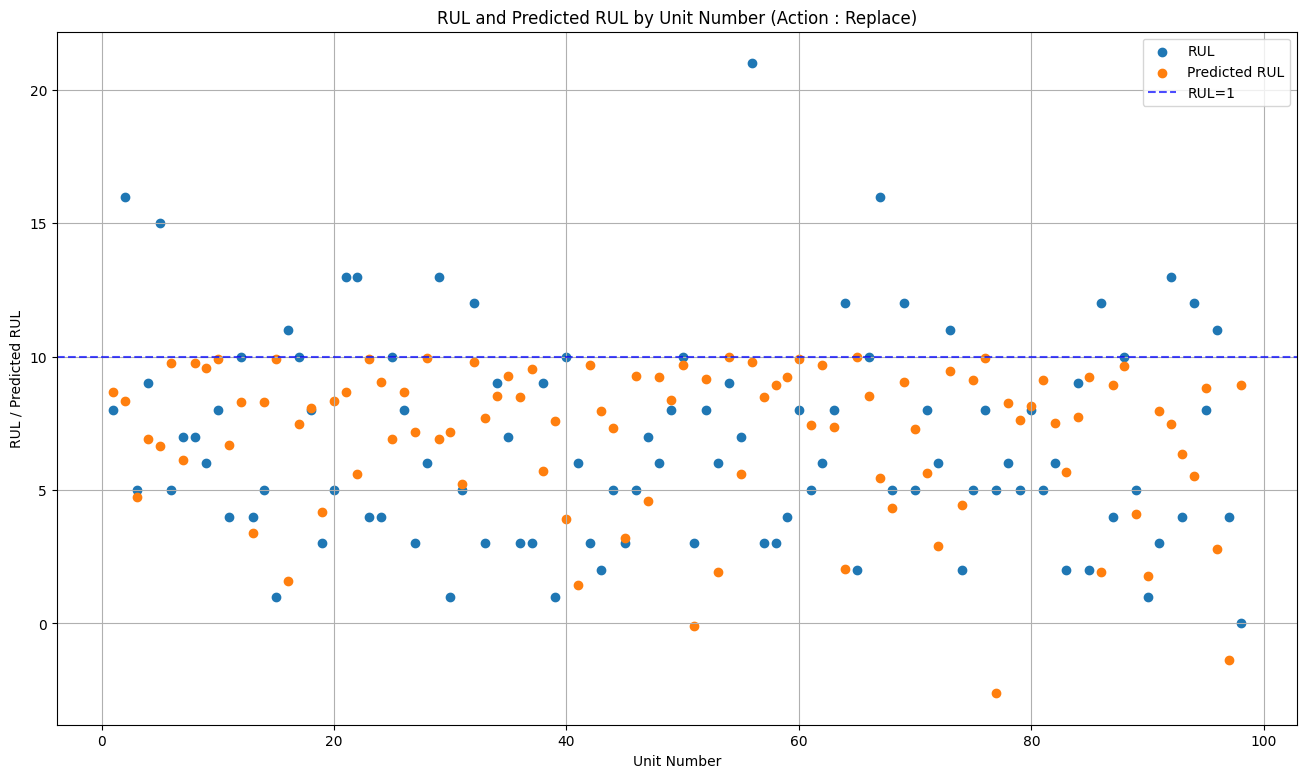

In [63]:
# 데이터프레임에서 'unit_number', 'RUL', 'predicted RUL' 열만 선택
data_to_plot = final_data.loc[replace_indices, ['unit_number', 'RUL', 'predicted RUL']]

# 'unit_number'를 x축으로, 'RUL'을 y축으로 하는 산점도 그리기
plt.figure(figsize=(16, 9))
plt.scatter(data_to_plot['unit_number'], data_to_plot['RUL'], label='RUL')
plt.scatter(data_to_plot['unit_number'], data_to_plot['predicted RUL'], label='Predicted RUL')

# index 5629인 data 추가 (replace failure)
#data_5629 = final_data.loc[5629, ['unit_number', 'RUL', 'predicted RUL']]
#plt.scatter(data_5629['unit_number'], data_5629['RUL'], c='tab:blue')
#plt.scatter(data_5629['unit_number'], data_5629['predicted RUL'], c='tab:orange')

# unit_number 28에 수직 점선 추가 (replace failure가 보이도록)
#unit_28_data = data_to_plot[data_to_plot['unit_number'] == 28]
#plt.axvline(x=28, color='red', linestyle='--', alpha = 0.3, label='Replace failure')
# 점선 옆에 text 추가
#plt.text(29, 26, 'Unit 28 (replace failure)', rotation=0, color='red')

# RUL = 10 점선 추가 (threshold)
plt.axhline(y=10, color='blue', linestyle='--', label='RUL=1', alpha = 0.7)

plt.xlabel('Unit Number')
plt.ylabel('RUL / Predicted RUL')
plt.title('RUL and Predicted RUL by Unit Number (Action : Replace)')
plt.legend()
plt.grid(True)
plt.show()

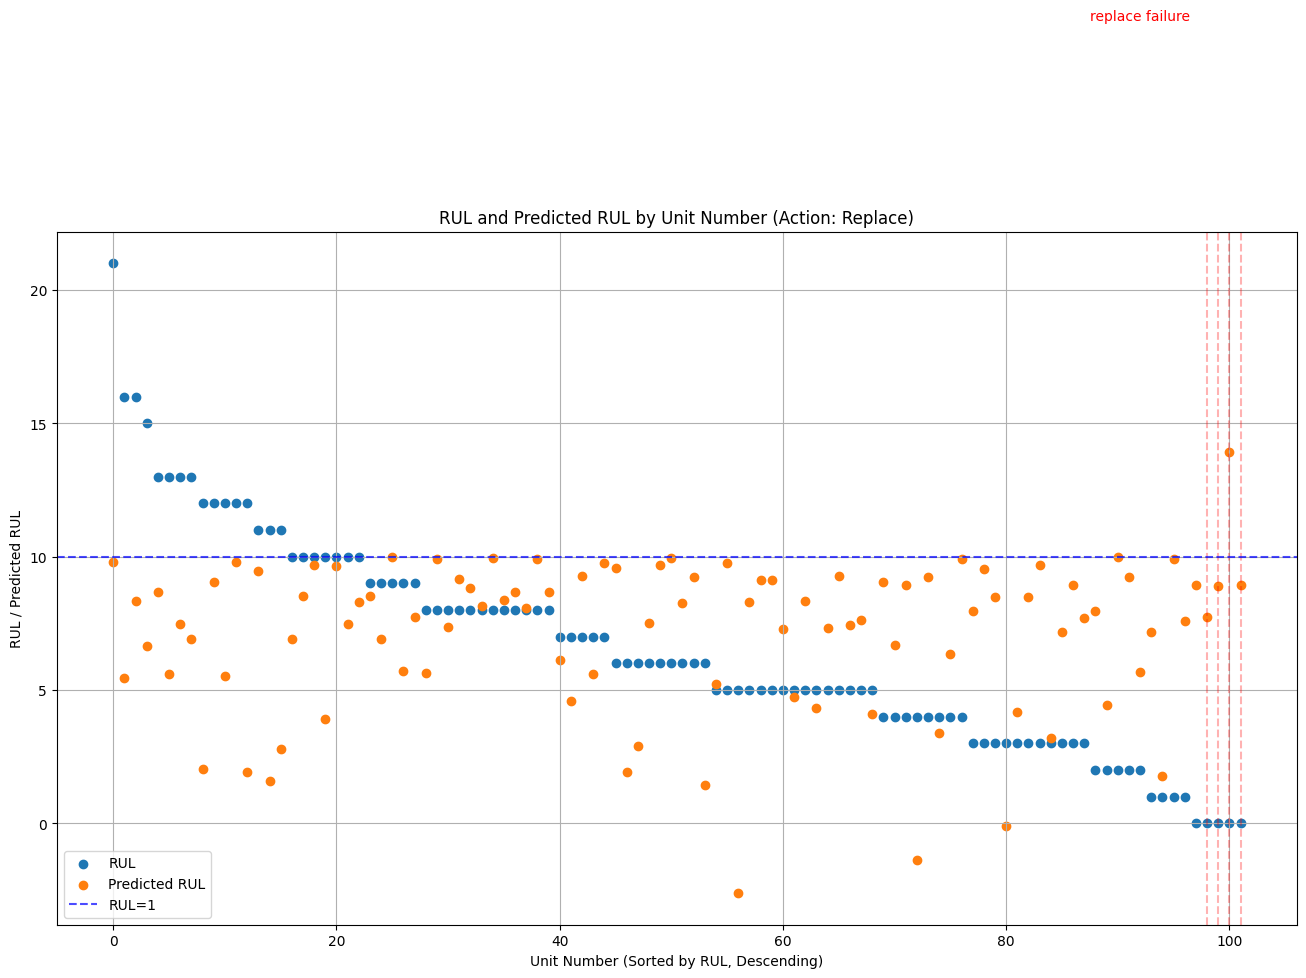

In [64]:
# 데이터프레임에서 'unit_number', 'RUL', 'predicted RUL' 열만 선택
data_to_plot = final_data.loc[replace_indices, ['unit_number', 'RUL', 'predicted RUL']]

# 'unit_number'를 RUL을 기준으로 내림차순으로 정렬하여 정렬된 순서를 저장
sorted_order = data_to_plot.sort_values(by='RUL', ascending=False).index

# 그래프 그리기
plt.figure(figsize=(16, 9))
plt.scatter(range(len(data_to_plot)), data_to_plot.loc[sorted_order, 'RUL'], label='RUL')
plt.scatter(range(len(data_to_plot)), data_to_plot.loc[sorted_order, 'predicted RUL'], label='Predicted RUL')

# index 3095, 7315, 12916, 20245인 data 추가 (replace failure), sorting 된 plot 오른쪽 끝에 삽입.
failure_1 = final_data.loc[3095, ['unit_number', 'RUL', 'predicted RUL']]
failure_2 = final_data.loc[7315, ['unit_number', 'RUL', 'predicted RUL']]
failure_3 = final_data.loc[12916, ['unit_number', 'RUL', 'predicted RUL']]
failure_4 = final_data.loc[20245, ['unit_number', 'RUL', 'predicted RUL']]

plt.scatter(len(data_to_plot), failure_1['RUL'], c='tab:blue')
plt.scatter(len(data_to_plot), failure_1['predicted RUL'], c='tab:orange')
plt.scatter(len(data_to_plot) + 1, failure_2['RUL'], c='tab:blue')
plt.scatter(len(data_to_plot) + 1, failure_2['predicted RUL'], c='tab:orange')
plt.scatter(len(data_to_plot) + 2, failure_3['RUL'], c='tab:blue')
plt.scatter(len(data_to_plot) + 2, failure_3['predicted RUL'], c='tab:orange')
plt.scatter(len(data_to_plot) + 3, failure_4['RUL'], c='tab:blue')
plt.scatter(len(data_to_plot) + 3, failure_4['predicted RUL'], c='tab:orange')

# index 3095, 7315, 12916, 20245에 수직 점선 추가 (replace failure 강조)
plt.axvline(x=len(data_to_plot), color='red', linestyle='--', alpha=0.3)
plt.axvline(x=len(data_to_plot) + 1, color='red', linestyle='--', alpha=0.3)
plt.axvline(x=len(data_to_plot) + 2, color='red', linestyle='--', alpha=0.3)
plt.axvline(x=len(data_to_plot) + 3, color='red', linestyle='--', alpha=0.3)

# replace failure 문구 추가.
plt.text(x=(len(data_to_plot) - 6), y=30, s='replace failure', fontsize=10, ha='center', va='bottom', color='red')


# RUL = 10 점선 추가 (threshold)
plt.axhline(y=10, color='blue', linestyle='--', label='RUL=1', alpha = 0.7)





plt.xlabel('Unit Number (Sorted by RUL, Descending)')
plt.ylabel('RUL / Predicted RUL')
plt.title('RUL and Predicted RUL by Unit Number (Action: Replace)')
plt.legend()
plt.grid(True)
plt.show()

**List comprehension으로 모든 값에서 1을 뺌 (replace 직전 index의 predicted_RUL) 확인을 위해**

In [65]:
before_replace_indices = [index - 1 for index in replace_indices]

In [66]:
for index in before_replace_indices:
    # final_data에서 해당 인덱스의 행 선택하여 필요한 열 출력
    row = final_data.loc[[index], ['unit_number', 'RUL', 'predicted RUL']]
    print(row)

     unit_number  RUL  predicted RUL
182            1    9      25.898757
     unit_number  RUL  predicted RUL
461            2   17       25.58472
     unit_number  RUL  predicted RUL
651            3    6       15.27727
     unit_number  RUL  predicted RUL
836            4   10      10.312255
      unit_number  RUL  predicted RUL
1099            5   16      16.998342
      unit_number  RUL  predicted RUL
1297            6    6      16.862659
      unit_number  RUL  predicted RUL
1554            7    8      15.037859
      unit_number  RUL  predicted RUL
1704            8    8      17.395731
      unit_number  RUL  predicted RUL
1906            9    7      16.053841
      unit_number  RUL  predicted RUL
2126           10    9      14.867836
      unit_number  RUL  predicted RUL
2370           11    5      11.927256
      unit_number  RUL  predicted RUL
2534           12   11      23.865903
      unit_number  RUL  predicted RUL
2703           13    5      19.101142
      unit_number  R

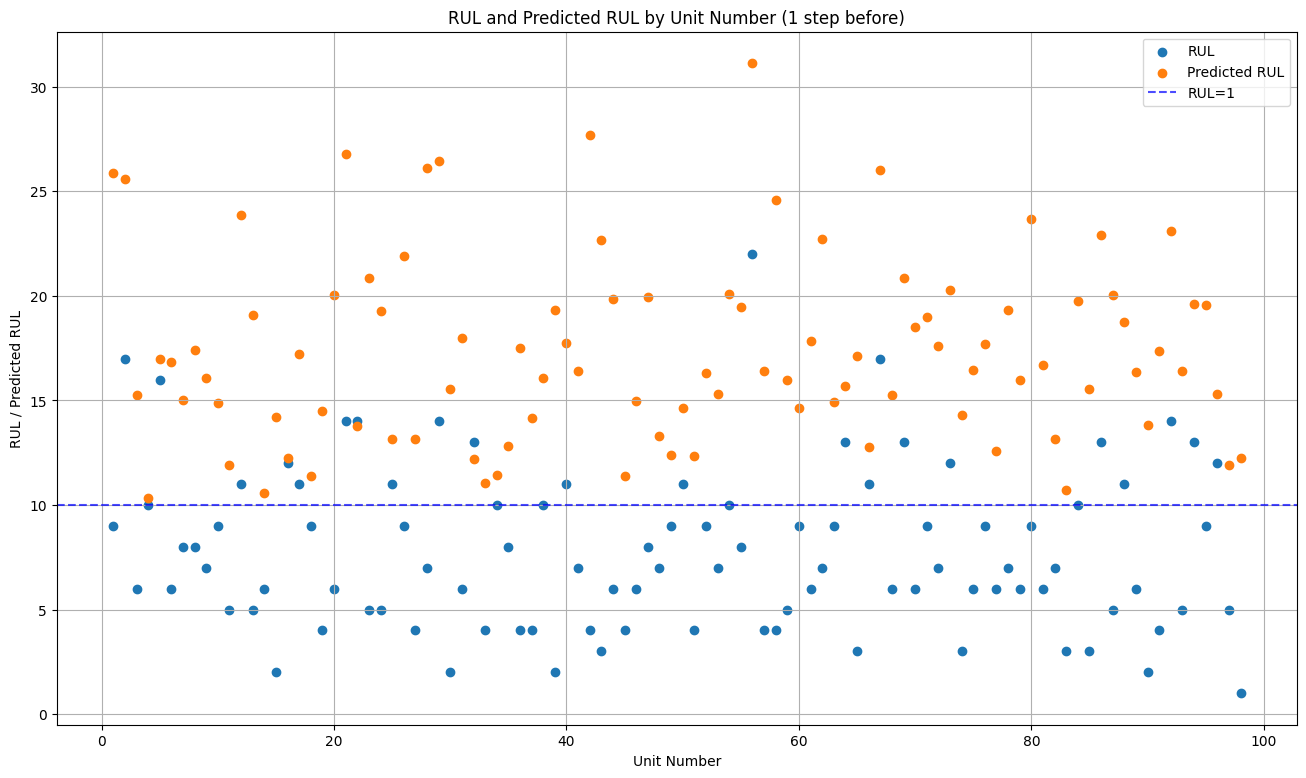

In [67]:
# 데이터프레임에서 'unit_number', 'RUL', 'predicted RUL' 열만 선택
data_to_plot = final_data.loc[before_replace_indices, ['unit_number', 'RUL', 'predicted RUL']]

# 'unit_number'를 x축으로, 'RUL'을 y축으로 하는 산점도 그리기
plt.figure(figsize=(16, 9))
plt.scatter(data_to_plot['unit_number'], data_to_plot['RUL'], label='RUL')
plt.scatter(data_to_plot['unit_number'], data_to_plot['predicted RUL'], label='Predicted RUL')

# index 5629인 data 추가 (replace failure)
#data_5629 = final_data.loc[5628, ['unit_number', 'RUL', 'predicted RUL']]
#plt.scatter(data_5629['unit_number'], data_5629['RUL'], c='tab:blue')
#plt.scatter(data_5629['unit_number'], data_5629['predicted RUL'], c='tab:orange')

# unit_number 28에 수직 점선 추가 (replace failure가 보이도록)
#unit_28_data = data_to_plot[data_to_plot['unit_number'] == 28]
#plt.axvline(x=28, color='red', linestyle='--', alpha = 0.3, label='Replace failure')
# 점선 옆에 text 추가
#plt.text(29, 25, 'Unit 28 (next step : replace failure)', rotation=0, color='red')

# RUL = 10 점선 추가 (threshold)
plt.axhline(y=10, color='blue', linestyle='--', label='RUL=1', alpha = 0.7)

plt.xlabel('Unit Number')
plt.ylabel('RUL / Predicted RUL')
plt.title('RUL and Predicted RUL by Unit Number (1 step before)')
plt.legend()
plt.grid(True)
plt.show()

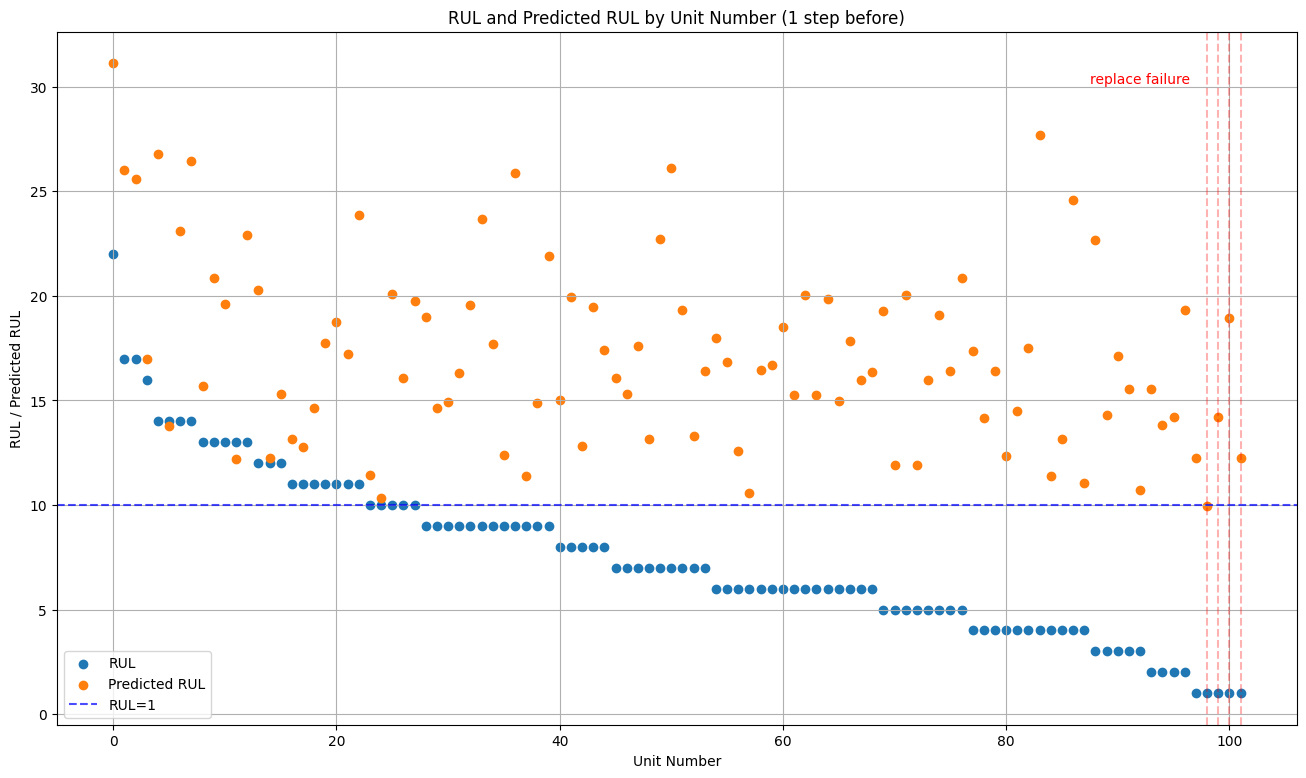

In [68]:
# 데이터프레임에서 'unit_number', 'RUL', 'predicted RUL' 열만 선택
data_to_plot = final_data.loc[before_replace_indices, ['unit_number', 'RUL', 'predicted RUL']]

# 'unit_number'를 RUL을 기준으로 내림차순으로 정렬하여 정렬된 순서를 저장
sorted_order = data_to_plot.sort_values(by='RUL', ascending=False).index

# 그래프 그리기
plt.figure(figsize=(16, 9))
plt.scatter(range(len(data_to_plot)), data_to_plot.loc[sorted_order, 'RUL'], label='RUL')
plt.scatter(range(len(data_to_plot)), data_to_plot.loc[sorted_order, 'predicted RUL'], label='Predicted RUL')


# index 3095, 7315, 12916, 20245의 1-step before data 추가 (replace failure), sorting 된 plot 오른쪽 끝에 삽입.
failure_before_1 = final_data.loc[3095 - 1, ['unit_number', 'RUL', 'predicted RUL']]
failure_before_2 = final_data.loc[7315 - 1, ['unit_number', 'RUL', 'predicted RUL']]
failure_before_3 = final_data.loc[12916 - 1, ['unit_number', 'RUL', 'predicted RUL']]
failure_before_4 = final_data.loc[20245 - 1, ['unit_number', 'RUL', 'predicted RUL']]

plt.scatter(len(data_to_plot), failure_before_1['RUL'], c='tab:blue')
plt.scatter(len(data_to_plot), failure_before_1['predicted RUL'], c='tab:orange')
plt.scatter(len(data_to_plot) + 1, failure_before_2['RUL'], c='tab:blue')
plt.scatter(len(data_to_plot) + 1, failure_before_2['predicted RUL'], c='tab:orange')
plt.scatter(len(data_to_plot) + 2, failure_before_3['RUL'], c='tab:blue')
plt.scatter(len(data_to_plot) + 2, failure_before_3['predicted RUL'], c='tab:orange')
plt.scatter(len(data_to_plot) + 3, failure_before_4['RUL'], c='tab:blue')
plt.scatter(len(data_to_plot) + 3, failure_before_4['predicted RUL'], c='tab:orange')

# index 3095, 7315, 12916, 20245에 수직 점선 추가 (replace failure 강조)
plt.axvline(x=len(data_to_plot), color='red', linestyle='--', alpha=0.3)
plt.axvline(x=len(data_to_plot) + 1, color='red', linestyle='--', alpha=0.3)
plt.axvline(x=len(data_to_plot) + 2, color='red', linestyle='--', alpha=0.3)
plt.axvline(x=len(data_to_plot) + 3, color='red', linestyle='--', alpha=0.3)

# replace failure 문구 추가.
plt.text(x=(len(data_to_plot) - 6), y=30, s='replace failure', fontsize=10, ha='center', va='bottom', color='red')



# RUL = 10 점선 추가 (threshold)
plt.axhline(y=10, color='blue', linestyle='--', label='RUL=1', alpha = 0.7)

plt.xlabel('Unit Number')
plt.ylabel('RUL / Predicted RUL')
plt.title('RUL and Predicted RUL by Unit Number (1 step before)')
plt.legend()
plt.grid(True)
plt.show()

**Q-continue와 Q-replace plot**

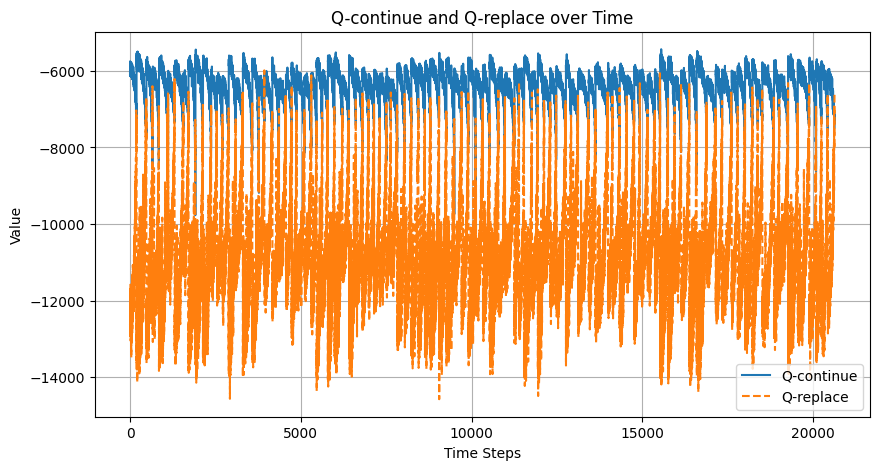

In [69]:
# 데이터 프레임에서 'Q-continue'와 'Q-replace' 열 선택
q_continue = RL_results['Q-continue']
q_replace = RL_results['Q-replace']

plt.figure(figsize=(10, 5))
plt.plot(q_continue, label='Q-continue', linestyle='-', alpha = 1)
plt.plot(q_replace, label='Q-replace', linestyle='--', alpha = 1)
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.legend()
plt.title('Q-continue and Q-replace over Time')
plt.grid(True)
plt.show()

**Replace failure 확인**

In [70]:
final_data.loc[[5629]]

,unit_number,time_cycles,setting_1,setting_2,setting_3,s_0,s_1,s_2,s_3,s_4,...,s_16,s_17,s_18,s_19,s_20,s_21,RUL,predicted RUL,Q-continue,Q-replace
5629,28,165,-0.0036,-0.0004,100.0,1,0.0,0.843373,0.644648,0.832546,...,0.0,0.666667,0.0,0.0,0.178295,0.354322,0,8.404868,-7426.507973,-7296.502969


**Online prediction 시각화**

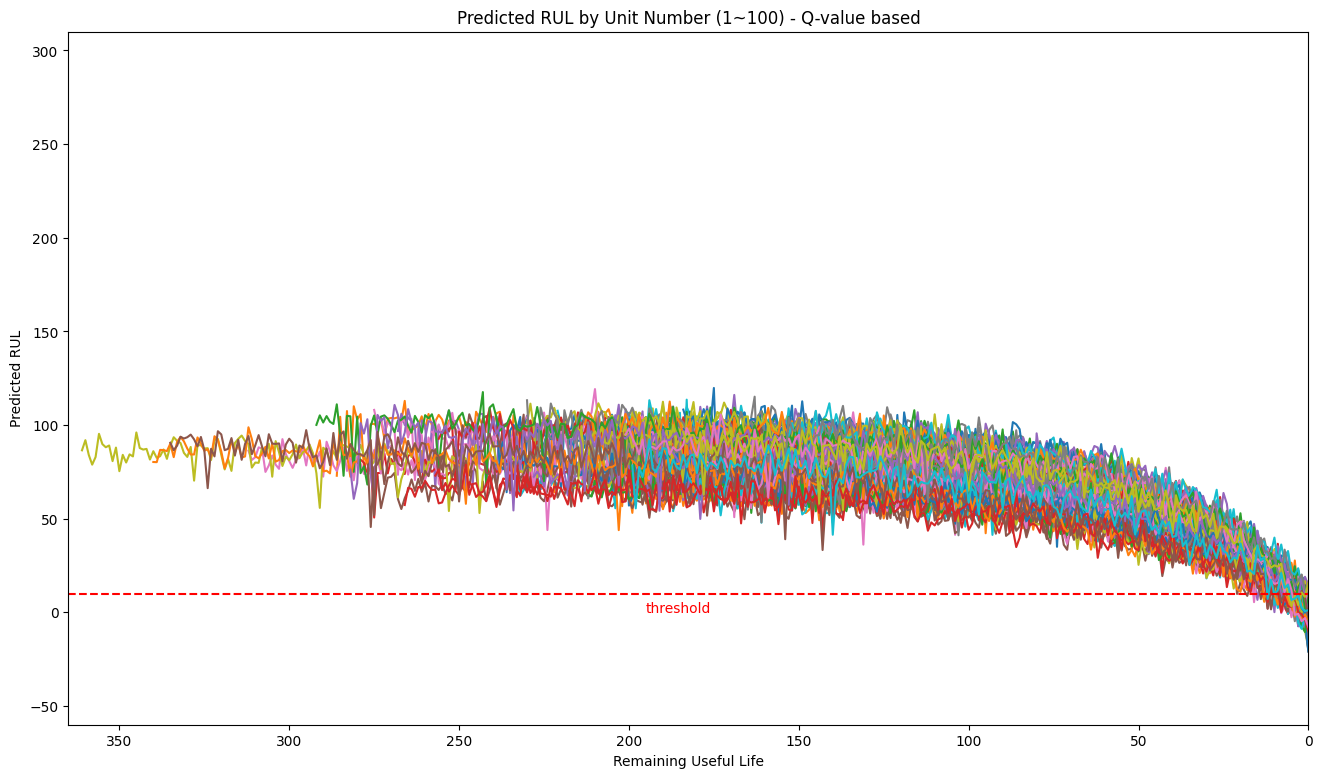

In [71]:
# 데이터프레임에서 unit_number을 기준으로 그룹화
grouped = final_data.groupby('unit_number')

# 그래프를 그릴 subplot을 설정
fig, ax = plt.subplots(figsize=(16, 9))

# unit_number 별로 그래프 그리기
for unit, group in grouped:
    ax.plot(group['RUL'], group['predicted RUL'], label=f'Unit {unit}')

ax.axhline(y=10, color='r', linestyle='--', label='threshold')  # threshold를 점선으로 표현
ax.text(195, 0, 'threshold', color='r')  # 'threshold' 텍스트 추가


ax.set_xlabel('Remaining Useful Life')
ax.set_ylabel('Predicted RUL')
ax.set_title(f'Predicted RUL by Unit Number (1~100) - Q-value based')
#ax.legend(loc='upper right')  # 범례 추가

# 그래프 출력 설정
plt.xlim(365, 0)  # reverse the x-axis so RUL counts down to zero
plt.ylim(-60, 310)
plt.show()

**online prediction 확대**

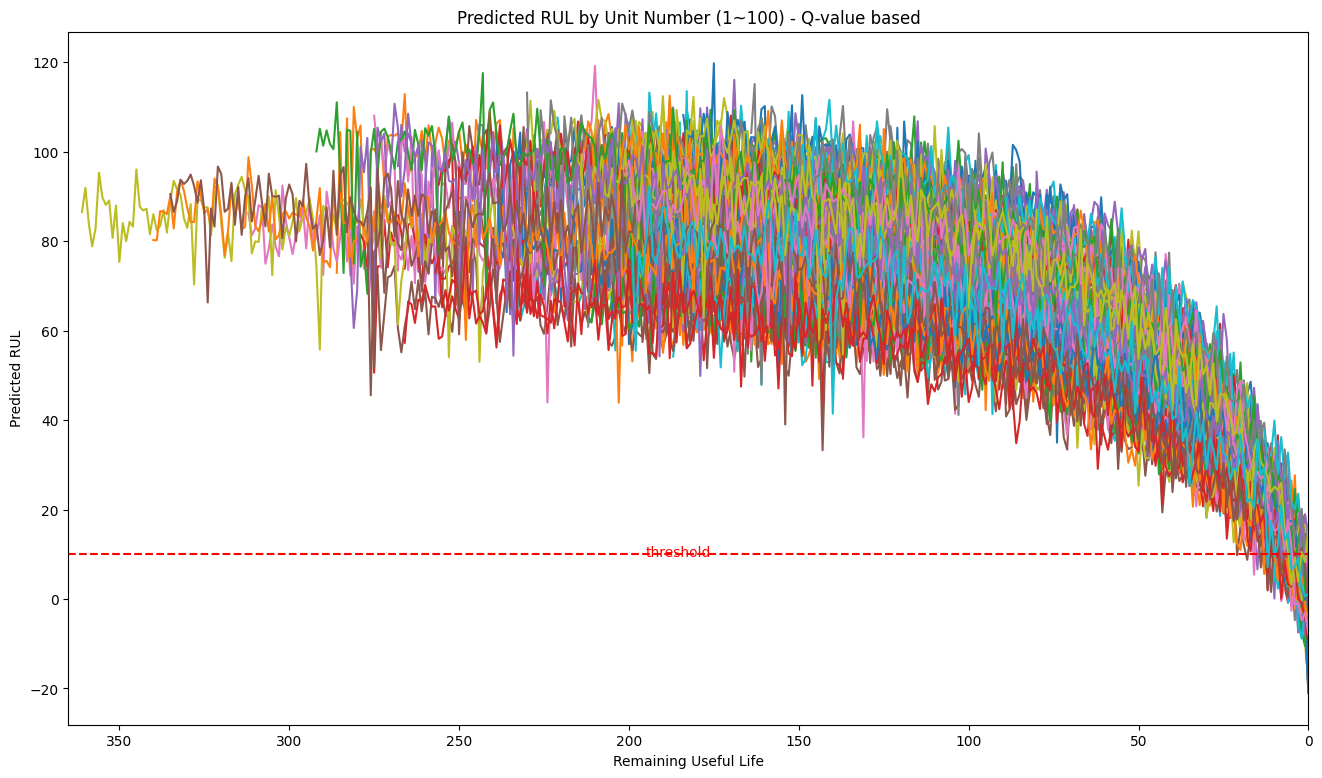

In [72]:
# 데이터프레임에서 unit_number을 기준으로 그룹화
grouped = final_data.groupby('unit_number')

# 그래프를 그릴 subplot을 설정
fig, ax = plt.subplots(figsize=(16, 9))

# unit_number 별로 그래프 그리기
for unit, group in grouped:
    ax.plot(group['RUL'], group['predicted RUL'], label=f'Unit {unit}')

ax.axhline(y=10, color='r', linestyle='--', label='threshold')  # threshold를 점선으로 표현
ax.text(195, 9.5, 'threshold', color='r')  # 'threshold' 텍스트 추가


ax.set_xlabel('Remaining Useful Life')
ax.set_ylabel('Predicted RUL')
ax.set_title(f'Predicted RUL by Unit Number (1~100) - Q-value based')
#ax.legend(loc='upper right')  # 범례 추가

# 그래프 출력 설정
plt.xlim(365, 0)  # reverse the x-axis so RUL counts down to zero
#plt.ylim(-60, 310)
plt.show()

**비교를 위해 unit_number 71~100만 출력.**

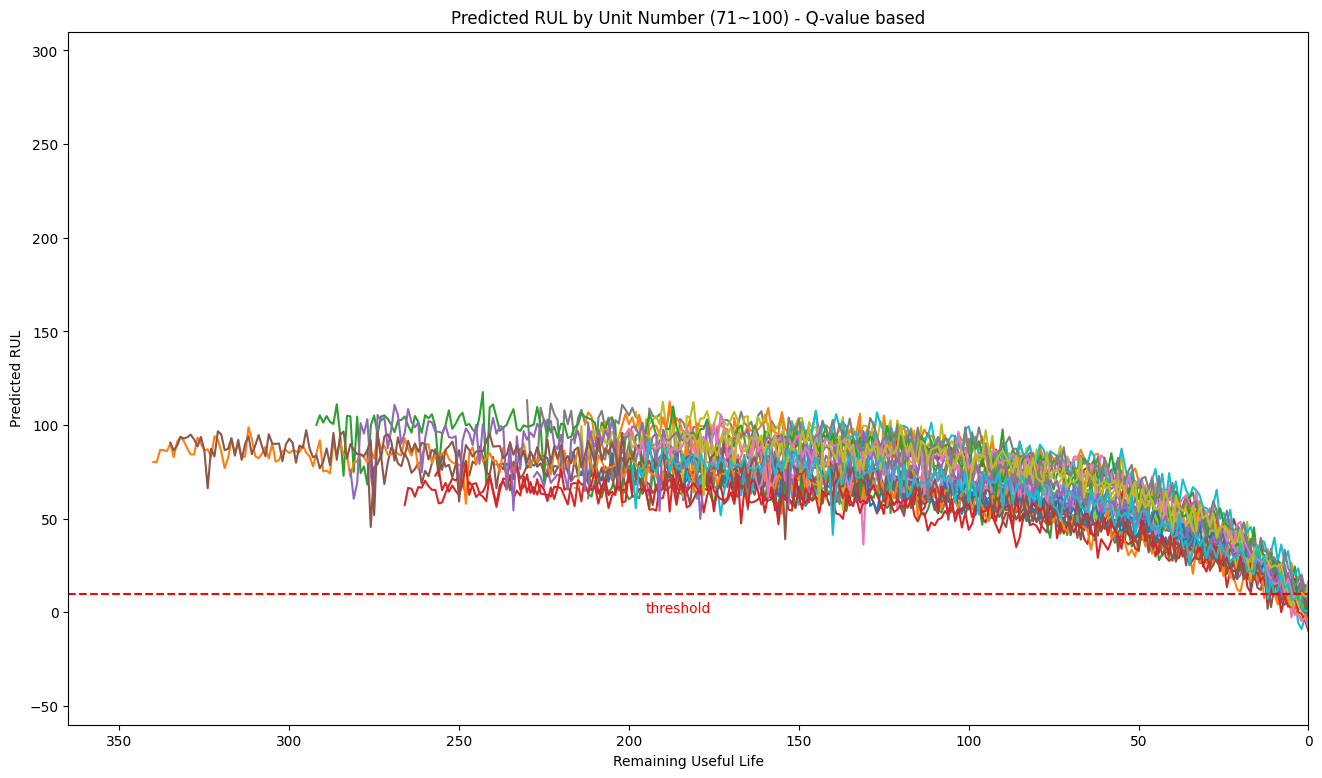

In [73]:
# 데이터프레임에서 unit_number을 기준으로 그룹화
filtered_data = final_data[(final_data['unit_number'] >= 71) & (final_data['unit_number'] <= 100)]  # 71~100 범위의 unit_number 필터링
grouped = filtered_data.groupby('unit_number')

# 그래프를 그릴 subplot을 설정
fig, ax = plt.subplots(figsize=(16, 9))

# unit_number 별로 그래프 그리기
for unit, group in grouped:
    ax.plot(group['RUL'], group['predicted RUL'], label=f'Unit {unit}')

ax.axhline(y=10, color='r', linestyle='--', label='threshold')  # threshold를 점선으로 표현
ax.text(195, 0, 'threshold', color='r')  # 'threshold' 텍스트 추가

ax.set_xlabel('Remaining Useful Life')
ax.set_ylabel('Predicted RUL')
ax.set_title(f'Predicted RUL by Unit Number (71~100) - Q-value based')

# 범례 추가
#ax.legend(loc='upper right')

# 그래프 출력 설정
plt.xlim(365, 0)  # reverse the x-axis so RUL counts down to zero
plt.ylim(-60, 310)
plt.show()

**online prediction 확대**

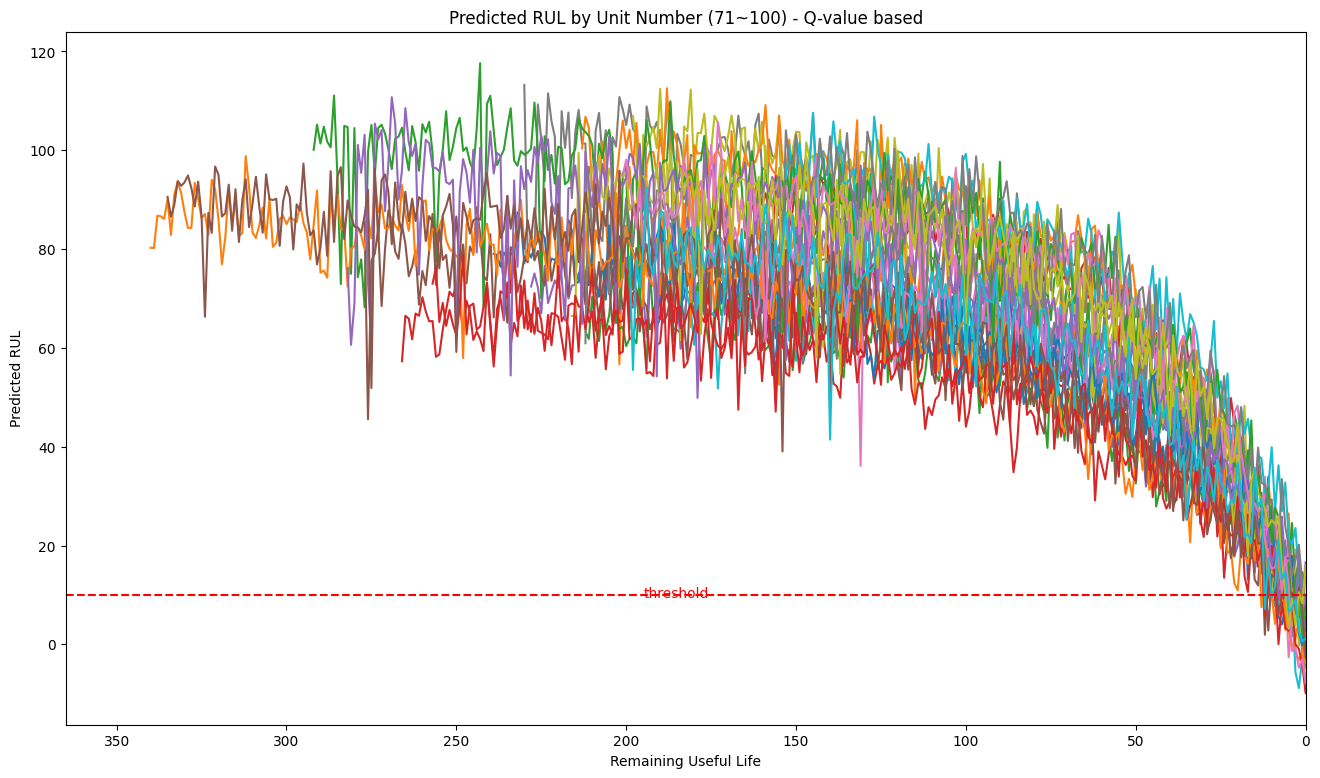

In [74]:
# 데이터프레임에서 unit_number을 기준으로 그룹화
filtered_data = final_data[(final_data['unit_number'] >= 71) & (final_data['unit_number'] <= 100)]  # 71~100 범위의 unit_number 필터링
grouped = filtered_data.groupby('unit_number')

# 그래프를 그릴 subplot을 설정
fig, ax = plt.subplots(figsize=(16, 9))

# unit_number 별로 그래프 그리기
for unit, group in grouped:
    ax.plot(group['RUL'], group['predicted RUL'], label=f'Unit {unit}')

ax.axhline(y=10, color='r', linestyle='--', label='threshold')  # threshold를 점선으로 표현
ax.text(195, 9.5, 'threshold', color='r')  # 'threshold' 텍스트 추가

ax.set_xlabel('Remaining Useful Life')
ax.set_ylabel('Predicted RUL')
ax.set_title(f'Predicted RUL by Unit Number (71~100) - Q-value based')

# 범례 추가
#ax.legend(loc='upper right')

# 그래프 출력 설정
plt.xlim(365, 0)  # reverse the x-axis so RUL counts down to zero
#plt.ylim(-60, 310)
plt.show()